# **Project Name-Cardiovascular Risk Assessment(CVD) Among diabetics patient**


# **Project Summary -**

This project focuses on predicting the 10-year risk of cardiovascular disease using machine learning techniques. Data were collected from Mzuzu Central Hospital and supplemented with the Framingham Heart Study dataset, which contains demographic, clinical, and laboratory information from 3,390 participants. After data preprocessing, including handling missing values, encoding categorical variables, and scaling numerical features, several machine learning models were trained and evaluated. The models tested included Logistic Regression, K-Nearest Neighbors (KNN), Support Vector Classifier (SVC), Random Forest, Naive Bayes, and XGBoost. Model performance was assessed using accuracy, precision, recall, and AUC-ROC metrics. Among the evaluated models, XGBoost achieved the best performance with an accuracy of 89% and an AUC-ROC of 0.89. Feature importance analysis identified age, education level, prevalent hypertension, and cigarettes per day as key predictors of cardiovascular risk. The developed model demonstrates the potential of machine learning to support early cardiovascular disease risk assessment and improve preventive healthcare interventions.

# **Problem Statement**


Cardiovascular disease is a leading cause of illness and death worldwide. Early identification of individuals at high risk is essential for effective prevention and treatment. Traditional risk prediction methods have limitations in accuracy and may not fully capture complex relationships among risk factors. This project aims to develop and evaluate a machine learning model for predicting the 10-year risk of cardiovascular disease using data from the Framingham Heart Study and clinical data collected at Mzuzu Central Hospital by the researcher Yosofati Malizani.


### Import Libraries

In [ ]:
## Data Maipulation Libraries
import numpy as np
import pandas as pd

## Data Visualisation Libraray
import matplotlib.pyplot as plt
%matplotlib inline
import pylab
import seaborn as sns
import joblib

## Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.svm import SVC

## Importing essential libraries to check the accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

## Warnings
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
# Load Dataset
# Load Dataset
df = pd.read_csv('data_cardiovascular_risk.csv')


In [3]:
# Drop the diabetes column
df.drop(columns=['diabetes'], inplace=True)

# Verify the columns
print(df.columns)

Index(['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'totChol', 'sysBP', 'diaBP', 'BMI',
       'heartRate', 'glucose', 'TenYearCVD'],
      dtype='str')


### Dataset First View

In [4]:
# Dataset First Look
df.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCVD
0,0,64,2.0,F,YES,3.0,0.0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [5]:
df.tail()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCVD
3385,3385,60,1.0,F,NO,0.0,0.0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,3386,46,1.0,F,NO,0.0,0.0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,3387,44,3.0,M,YES,3.0,0.0,0,1,352.0,164.0,119.0,28.92,73.0,72.0,1
3388,3388,60,1.0,M,NO,0.0,NaN,0,1,191.0,167.0,105.0,23.01,80.0,85.0,0
3389,3389,54,3.0,F,NO,0.0,0.0,0,0,288.0,124.0,77.0,29.88,79.0,92.0,0


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
df.shape

(3390, 16)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   str    
 4   is_smoking       3390 non-null   str    
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   totChol          3352 non-null   float64
 10  sysBP            3390 non-null   float64
 11  diaBP            3390 non-null   float64
 12  BMI              3376 non-null   float64
 13  heartRate        3389 non-null   float64
 14  glucose          3086 non-null   float64
 15  TenYearCVD       3390 non-null   int64  
dtypes: float64(9), int64(5), str(2)
memory usage: 435.5 KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
df.isnull().sum()

id                   0
age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCVD           0
dtype: int64

## ***2. Understanding Variables***

In [10]:
# Dataset Columns
df.columns

Index(['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'totChol', 'sysBP', 'diaBP', 'BMI',
       'heartRate', 'glucose', 'TenYearCVD'],
      dtype='str')

In [11]:
# Dataset Describe
df.describe(include="all")

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCVD
count,3390.000000,3390.000000,3303.000000,3390,3390,3368.000000,3346.000000,3390.000000,3390.000000,3352.000000,3390.00000,3390.000000,3376.000000,3389.000000,3086.000000,3390.000000
unique,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,F,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1923,1703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1694.500000,49.542183,1.970936,NaN,NaN,9.069477,0.029886,0.006490,0.315339,237.074284,132.60118,82.883038,25.794964,75.977279,82.086520,0.150737
std,978.753033,8.592878,1.019081,NaN,NaN,11.879078,0.170299,0.080309,0.464719,45.247430,22.29203,12.023581,4.115449,11.971868,24.244753,0.357846
min,0.000000,32.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,107.000000,83.50000,48.000000,15.960000,45.000000,40.000000,0.000000
25%,847.250000,42.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,206.000000,117.00000,74.500000,23.020000,68.000000,71.000000,0.000000
50%,1694.500000,49.000000,2.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,234.000000,128.50000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,2541.750000,56.000000,3.000000,NaN,NaN,20.000000,0.000000,0.000000,1.000000,264.000000,144.00000,90.000000,28.040000,83.000000,87.000000,0.000000


### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in ", i , "is" , df[i].nunique(), ".")

No. of unique values in  id is 3390 .
No. of unique values in  age is 39 .
No. of unique values in  education is 4 .
No. of unique values in  sex is 2 .
No. of unique values in  is_smoking is 2 .
No. of unique values in  cigsPerDay is 32 .
No. of unique values in  BPMeds is 2 .
No. of unique values in  prevalentStroke is 2 .
No. of unique values in  prevalentHyp is 2 .
No. of unique values in  totChol is 240 .
No. of unique values in  sysBP is 226 .
No. of unique values in  diaBP is 142 .
No. of unique values in  BMI is 1259 .
No. of unique values in  heartRate is 68 .
No. of unique values in  glucose is 132 .
No. of unique values in  TenYearCVD is 2 .


## 3. ***Data Wrangling***

In [13]:
# Separating the categorical and continous variable and storing them
categorical_variable=[]
continous_variable=[]

for i in df.columns:
  if i == 'id':
    pass
  elif df[i].nunique() <5:
    categorical_variable.append(i)
  elif df[i].nunique() >= 5:
    continous_variable.append(i)

print(categorical_variable)
print(continous_variable)

['education', 'sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'TenYearCVD']
['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


In [14]:
df

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCVD
0,0,64,2.0,F,YES,3.0,0.0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,3385,60,1.0,F,NO,0.0,0.0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,3386,46,1.0,F,NO,0.0,0.0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,3387,44,3.0,M,YES,3.0,0.0,0,1,352.0,164.0,119.0,28.92,73.0,72.0,1
3388,3388,60,1.0,M,NO,0.0,NaN,0,1,191.0,167.0,105.0,23.01,80.0,85.0,0


In [15]:
# Summing null values
print('Missing Data Count')
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

Missing Data Count


glucose       304
education      87
BPMeds         44
totChol        38
cigsPerDay     22
BMI            14
heartRate       1
dtype: int64

In [16]:
print('Missing Data Percentage')
print(round(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)/len(df)*100,2))

Missing Data Percentage
glucose       8.97
education     2.57
BPMeds        1.30
totChol       1.12
cigsPerDay    0.65
BMI           0.41
heartRate     0.03
dtype: float64


In [17]:
# storing the column that contains null values
null_column_list= ['glucose','education','BPMeds','totChol','cigsPerDay','BMI','heartRate']
# plotting box plot
plt.figure(figsize=(10,8))
df[null_column_list].boxplot()

<Axes: >

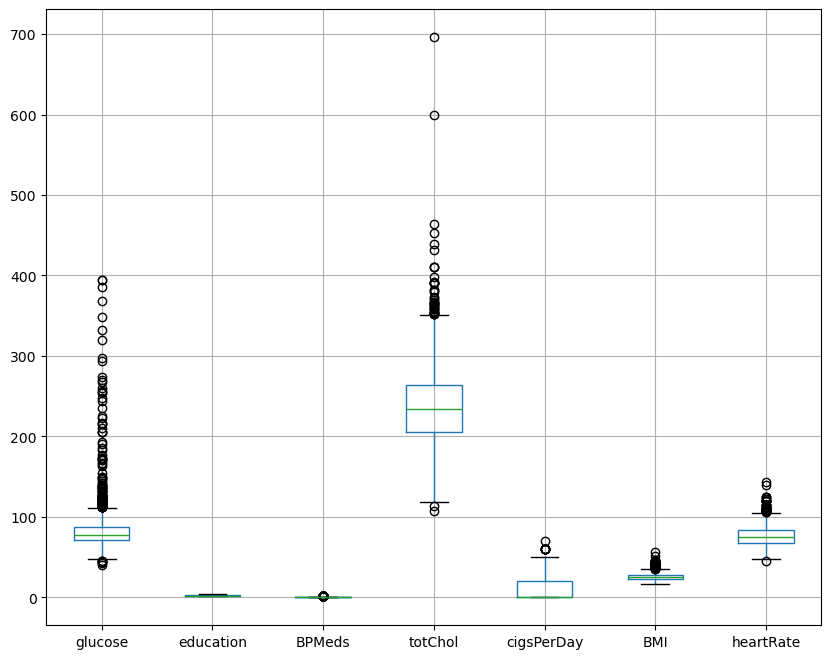

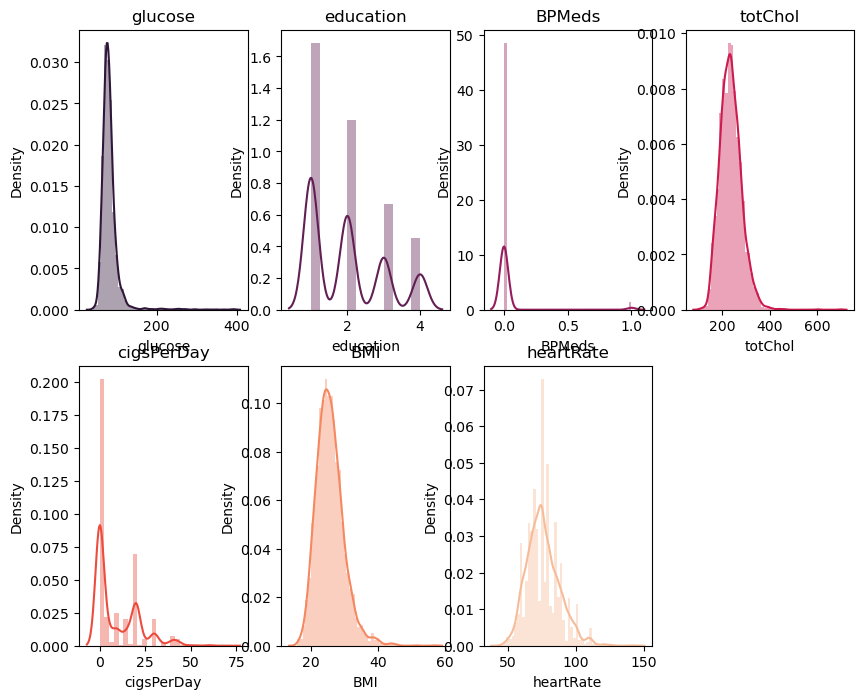

In [18]:
# Iterate over the null column list and plot each column's distribution
colors = sns.color_palette("rocket", len(null_column_list))


fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10, 8))


axes = axes.flatten()


for i, column in enumerate(null_column_list):
    ax = axes[i]

    sns.distplot(df[column], ax=ax, color=colors[i])
    ax.set_title(column)

for j in range(len(null_column_list), len(axes)):
    axes[j].remove()

plt.show()

* It is a well-known fact that the appropriate measure of central tendency depends on the nature of the data. Typically, the mean is used for data that follows a normal distribution and does not contain any outliers. On the other hand, when dealing with numerical, continuous data that contains extreme values or outliers, the median is the preferred measure of central tendency. For categorical data, the mode is used.

* Based on the outliers and distribution of the data, we have determined that the following measures of central tendency are appropriate for imputing the null values in the following columns.

* "education" , "BPMeds" -> mode: As "education" and "BPMeds" is a categorical variable, the mode is the most appropriate measure of central tendency. The mode represents the most frequently occurring value in the distribution and can provide insight into the most common level of education in the dataset.

* "glucose","totChol", "cigsPerDay", "BMI", "heartRate" -> median: Since this are numerical, continuous variable that contain extreme values or outliers, we have chosen the median as the appropriate measure of central tendency. The median is less sensitive to extreme values than the mean and provides a representative value for the central tendency of the distribution.

In [19]:
# Imputing missing values with median or mode
df.fillna({'glucose': df['glucose'].median(),
           'education': df['education'].mode()[0],
           'BPMeds': df['BPMeds'].mode()[0],
           'totChol': df['totChol'].median(),
           'cigsPerDay': df['cigsPerDay'].median(),
           'BMI': df['BMI'].median(),
           'heartRate': df['heartRate'].median()}, inplace=True)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCVD
0,0,64,2.0,F,YES,3.0,0.0,0,0,221.0,148.0,85.0,25.38,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,3385,60,1.0,F,NO,0.0,0.0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,3386,46,1.0,F,NO,0.0,0.0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,3387,44,3.0,M,YES,3.0,0.0,0,1,352.0,164.0,119.0,28.92,73.0,72.0,1
3388,3388,60,1.0,M,NO,0.0,0.0,0,1,191.0,167.0,105.0,23.01,80.0,85.0,0


### What manipulations  i have done and  what insights i have gained ?

* performed imputation of missing values using a combination of median and mode imputation. Specifically, for the glucose and totChol columns, cigsPerDay, BMI, and heartRate the missing values are replaced with the median of the non-missing values. For the education, BPMeds columns, the missing values are replaced with the mode (most frequently occurring value) of the non-missing values.

* Median and mode imputation are commonly used imputation techniques for handling missing values. Median imputation is often used for continuous variables, as it is less sensitive to outliers compared to mean imputation. Mode imputation is often used for categorical variables or discrete variables with a small number of possible values.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables*** ***bold text*** *italicized text*

#### Chart - 1

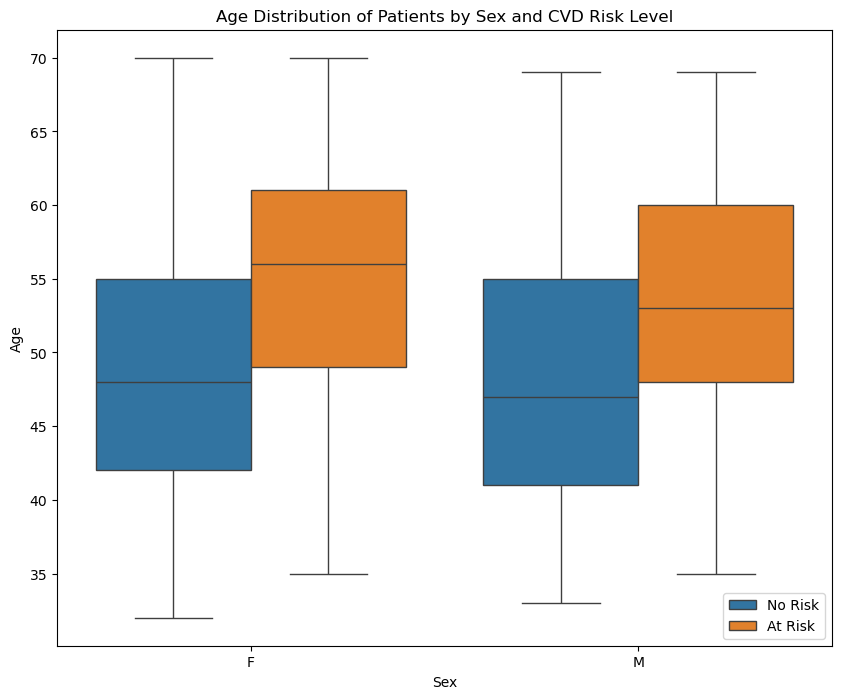

In [20]:
# Chart - 1 visualization code
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(x="sex", y="age", hue="TenYearCVD", data= df, ax=ax)
ax.set_title("Age Distribution of Patients by Sex and CVD Risk Level")
ax.set_xlabel("Sex")
ax.set_ylabel("Age")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["No Risk", "At Risk"], loc="best")
plt.show()



```
# This is formatted as code
```

##### 1. Why did I  pick this  chart?

* This chart is a boxplot that visualizes the age distribution of patients by sex and CVD risk level. It was likely chosen to gain insights into how age, sex, and CVD risk level may be related in this dataset.

2. What are insights i grain from the chart?

* There is a noticeable difference in the age distribution of patients who are at risk for CVD compared to those who are not at risk. Patients at risk for CVD tend to be older than those who are not at risk, regardless of sex.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The insights gained from this chart may be useful for businesses that provide healthcare services or products. For example, companies that produce medical devices or medications for CVD may want to consider targeting older patients or patients who are at higher risk for CVD. However, it is important to note that this chart alone may not provide enough information to make business decisions. Further analysis would be needed to fully understand the relationship between age, sex, CHD risk level, and other relevant factors. There are no insights from this chart that suggest negative growth.

#### Chart - 2

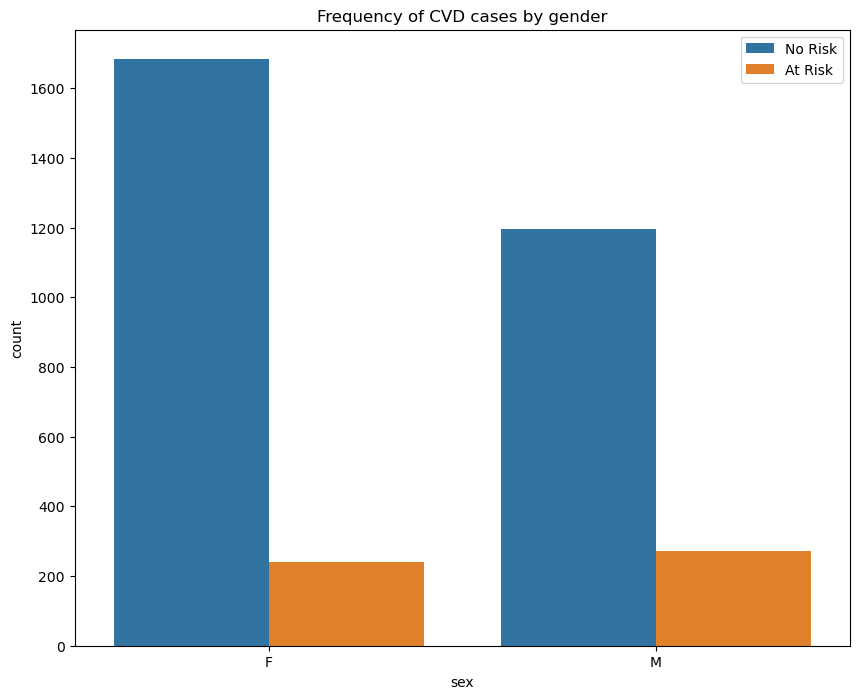

In [21]:
# Chart - 2 visualization code

plt.figure(figsize=(10,8))
sns.countplot(x='sex', hue='TenYearCVD', data= df)
plt.title('Frequency of CVD cases by gender')
plt.legend(['No Risk', 'At Risk'])
plt.show()

##### 1. Why did I  pick this chart?

* This chart is a countplot that visualizes the frequency of CVD cases by gender in the dataset. It was likely chosen to investigate whether gender affects the risk of CVD in the dataset.

##### 2. is there any  which insight(s) i  found from the chart?

* The chart shows that there are more cases of CVD among men than women in the dataset. However, this difference is not drastic, as the number of cases of CVD is relatively similar between men and women. Additionally, the chart shows that there are more cases of no risk for CVD among women compared to men.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The insights gained from this chart may be useful for businesses that provide healthcare services or products. For example, companies that produce medical devices or medications for CVD may want to consider targeting both men and women, but may want to focus more on men, who appear to be at higher risk for CVD in this dataset.

#### Chart - 3

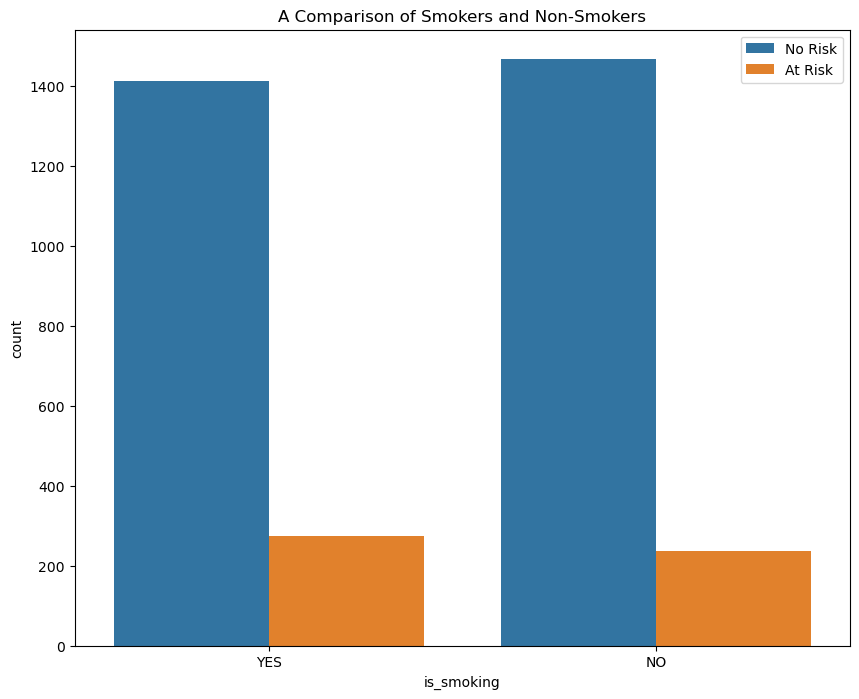

In [22]:
# Chart - 3 visualization code
plt.figure(figsize=(10,8))
sns.countplot(x='is_smoking', hue='TenYearCVD', data= df)
plt.title('A Comparison of Smokers and Non-Smokers')
plt.legend(['No Risk', 'At Risk'])
plt.show()

##### 1. What push me to choose this chart?

* This chart is a countplot that visualizes the frequency of CVD cases among smokers and non-smokers. It was likely chosen to gain insights into how smoking may be related to the risk of CVD in this dataset.

##### 2. is there any insights that a gain from this chart?

* The chart shows that patients who smoke appear to be at higher risk for CVD than those who do not smoke in this dataset. Specifically, a higher proportion of patients who smoke are at risk for CVD compared to those who do not smoke. These findings suggest that smoking may be a factor in determining the risk of CVD in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* There are no insights from this chart that suggest negative growth. This chart only shows the frequency of CVD cases among smokers and non-smokers, and does not provide information on other factors that may be relevant for businesses, such as age or other lifestyle factors. Additionally, the dataset may not be representative of the population as a whole, which could limit the generalizability of the insights gained from this chart.

#### Chart - 4

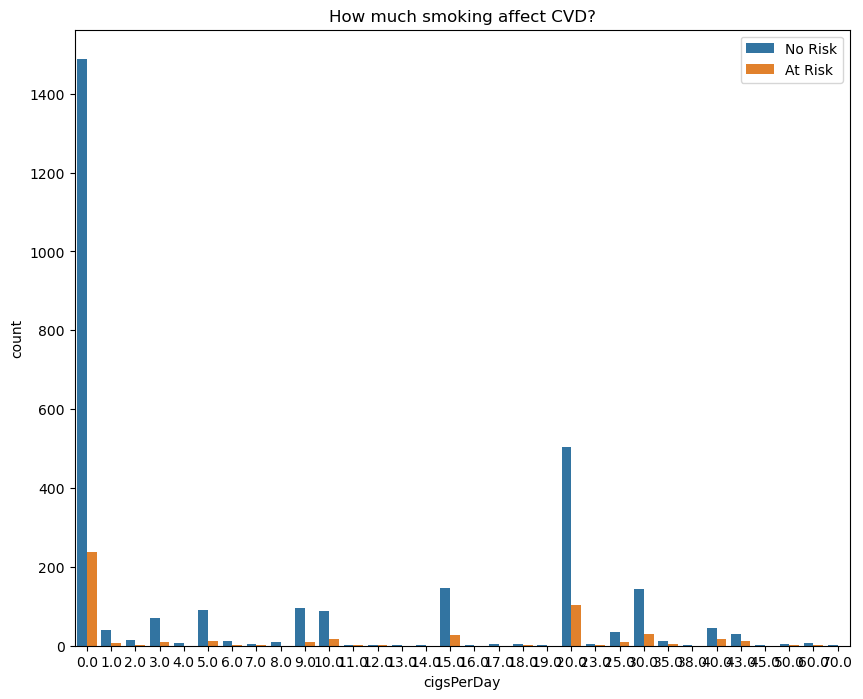

In [23]:
# Chart - 4 visualization code
plt.figure(figsize=(10,8))
sns.countplot(x= df['cigsPerDay'],hue= df['TenYearCVD'])
plt.title('How much smoking affect CVD?')
plt.legend(['No Risk','At Risk'])
plt.show()

##### 1. Why have this chart?

* This chart is a countplot that visualizes the relationship between the number of cigarettes smoked per day and the risk of CVD in this dataset. It was likely chosen to gain insights into how smoking intensity may be related to CVD risk.

##### 2. What is/are the insight(s) found from the chart?

* The chart shows that patients who smoke more cigarettes per day or do not smoke appear to be at higher risk for CVD than those who smoke fewer cigarettes per day. Specifically, a higher proportion of patients who smoke 20 or more cigarettes per day are at risk for CVD compared to those who smoke fewer cigarettes per day. These findings suggest that smoking intensity may be a factor in determining the risk of CVD in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Companies that produce smoking cessation aids or medications for CVD may want to consider targeting heavy smokers, as they appear to be at higher risk for CVD in this dataset.

#### Chart - 5

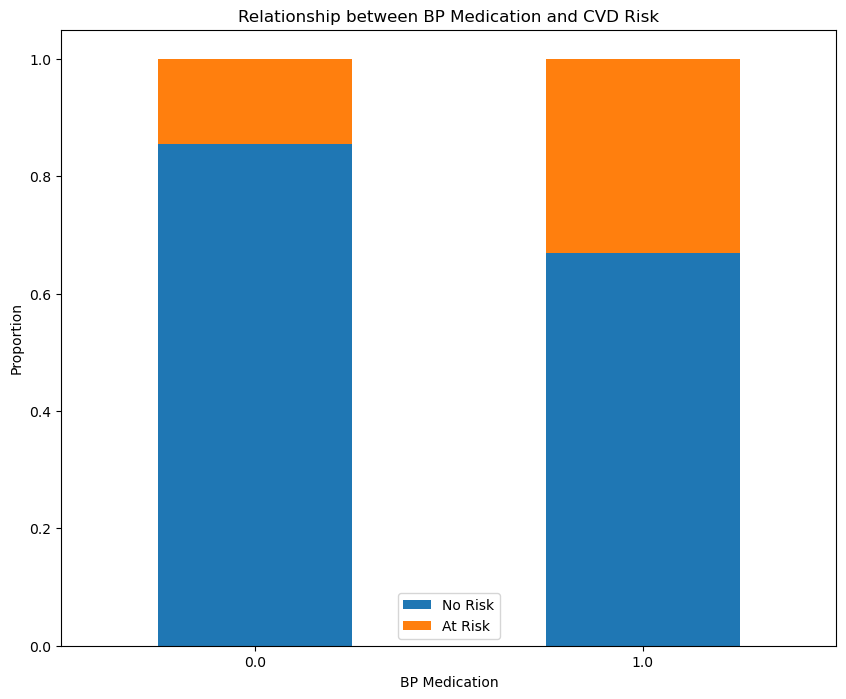

In [24]:
# Chart - 5 visualization code
ct = pd.crosstab(df['BPMeds'], df['TenYearCVD'], normalize='index')
ct.plot(kind='bar', stacked=True, figsize=(10, 8))
plt.title('Relationship between BP Medication and CVD Risk')
plt.xlabel('BP Medication')
plt.xticks(rotation=0)
plt.ylabel('Proportion')
plt.legend(['No Risk', 'At Risk'])
plt.show()

##### 1. Why did I  pick the specific chart?

> Add blockquote



* This chart is a stacked bar chart that shows the relationship between whether a patient takes medication for blood pressure and their risk of CVD. It was likely chosen to investigate whether BP medication use is associated with CVD risk in this dataset.

##### 2. What is/are the insight(s) found from the chart?

* The chart shows that patients who take medication for blood pressure appear to be at higher risk for CVD compared to those who do not take medication for blood pressure. Specifically, the proportion of patients who are at risk for CVD is not similar for those who take medication for blood pressure and those who do not. These findings suggest that BP medication use may be a significant factor in determining CVD risk in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Companies that produce BP medication or other treatments for hypertension may want to consider targeting patients with high blood pressure who are at risk for CVD, regardless of whether they are currently taking medication for blood pressure. This approach may help identify patients who would benefit from more aggressive treatment to reduce their risk of CVD.

#### Chart - 6

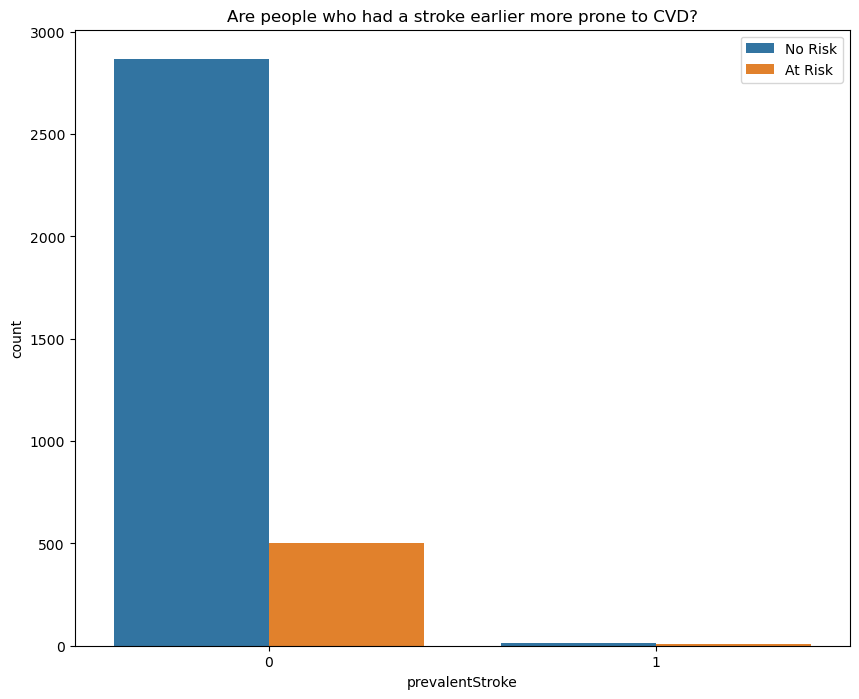

In [25]:
# Chart - 6 visualization code
plt.figure(figsize=(10,8))
sns.countplot(x=df['prevalentStroke'], hue=df['TenYearCVD'])
plt.title('Are people who had a stroke earlier more prone to CVD?')
plt.legend(['No Risk', 'At Risk'], loc='best')
plt.show()


##### 1. Why did I  pick this specific chart?

* This chart is a countplot that compares the CvD risk level of patients who have had a prevalent stroke versus those who have not. It was likely chosen to investigate whether there is an association between having a stroke and being more susceptible to CvD.

##### 2. What is/are the insight(s) found from the chart?

* The chart shows that patients who have had a prevalent stroke appear to be at higher risk for CvD compared to those who have not. Specifically, the proportion of patients who are at risk for CvD is higher among those who have had a stroke compared to those who have not. These findings suggest that having a stroke may be a risk factor for developing CvD in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The insights gained from this chart may be useful for businesses that provide healthcare services or products related to stroke or CvD. For example, companies that produce medications or treatments for stroke or CvD may want to consider targeting patients who have had a stroke as a high-risk population for CvD.

* Healthcare providers may want to screen patients who have had a stroke for CvD risk and provide appropriate preventative measures or treatments.

#### Chart - 7

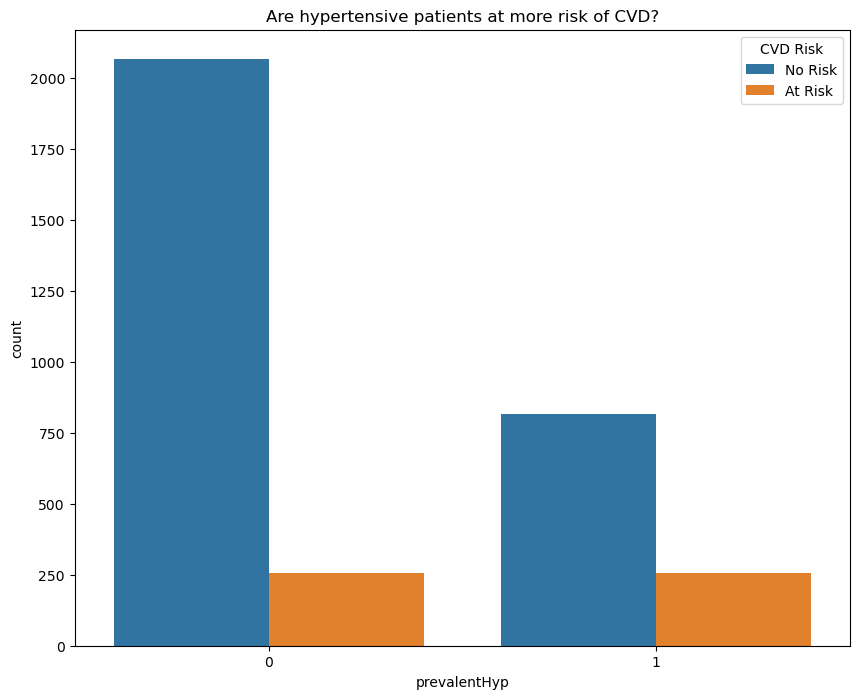

In [26]:
# Chart - 7 visualization code
plt.figure(figsize=(10,8))
sns.countplot(x=df['prevalentHyp'], hue=df['TenYearCVD'])
plt.title('Are hypertensive patients at more risk of CVD?')
plt.legend(title='CVD Risk', labels=['No Risk', 'At Risk'])
plt.show()

##### 1. Why did I  pick this specific chart?

* This chart was picked to visualize the relationship between prevalent hypertension and the risk of developing CVD in the dataset.

##### 2. What is/are the insight(s) found from the chart?

* The chart shows that patients with prevalent hypertension are more likely to be at risk of developing CVD disease compared to those without hypertension.

* Specifically, the proportion of patients who are at risk for CVD is similar for those who with prevalent hypertension and those who do not.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Yes, the gained insight can help healthcare businesses and professionals identify high-risk patients with hypertension who need further evaluation, monitoring, and management to prevent the development or progression of coronary heart disease.

* There are no insights that lead to negative growth in this chart.



#### Chart - 8

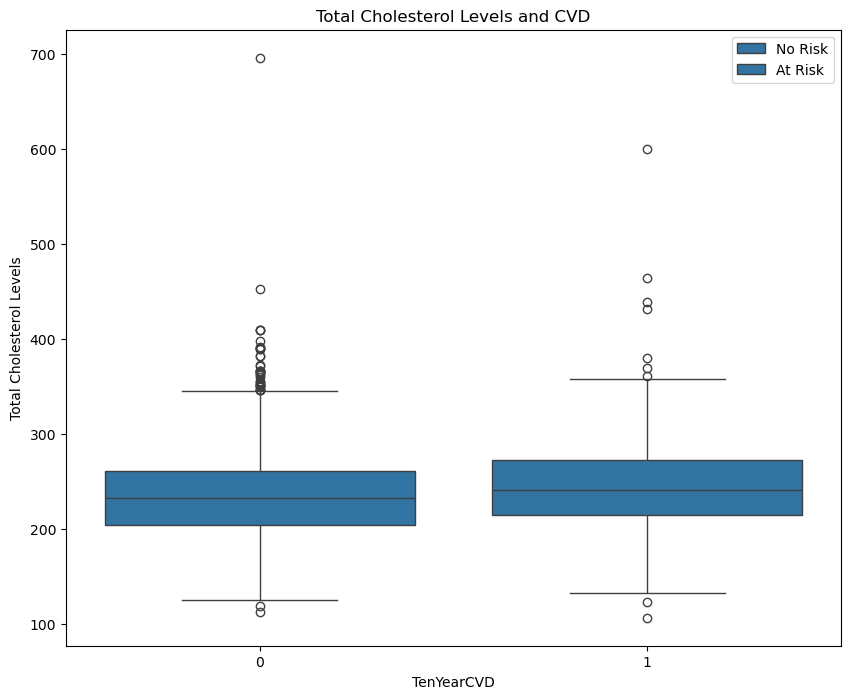

In [27]:
# Chart - 9 visualization code
plt.figure(figsize=(10,8))
sns.boxplot(x='TenYearCVD', y='totChol', data=df)
plt.title('Total Cholesterol Levels and CVD')
plt.xlabel('TenYearCVD')
plt.ylabel('Total Cholesterol Levels')
plt.legend(['No Risk', 'At Risk'])
plt.show()


##### 1. Why did I  pick thIS specific chart?

* The specific box plot was chosen to answer the question of whether there is a correlation between total cholesterol levels and the risk of developing CVD disease among diabetics patient.

##### 2. What is/are the insight(s) found from the chart?

* The box plot shows that patients who are at risk of developing CVD disease have slightly higher total cholesterol levels on average than those who are not at risk. There is some overlap in the range of cholesterol levels between the two groups

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The gained insight can help healthcare providers to consider the impact of total cholesterol levels on the risk of developing coronary heart disease in their patients. By identifying patients with high cholesterol levels, appropriate interventions can be implemented to lower their risk of developing the disease. This can have a positive impact on patient health outcomes and lead to cost savings for healthcare providers in the long run.

#### Chart - 10

<Figure size 1500x1000 with 0 Axes>

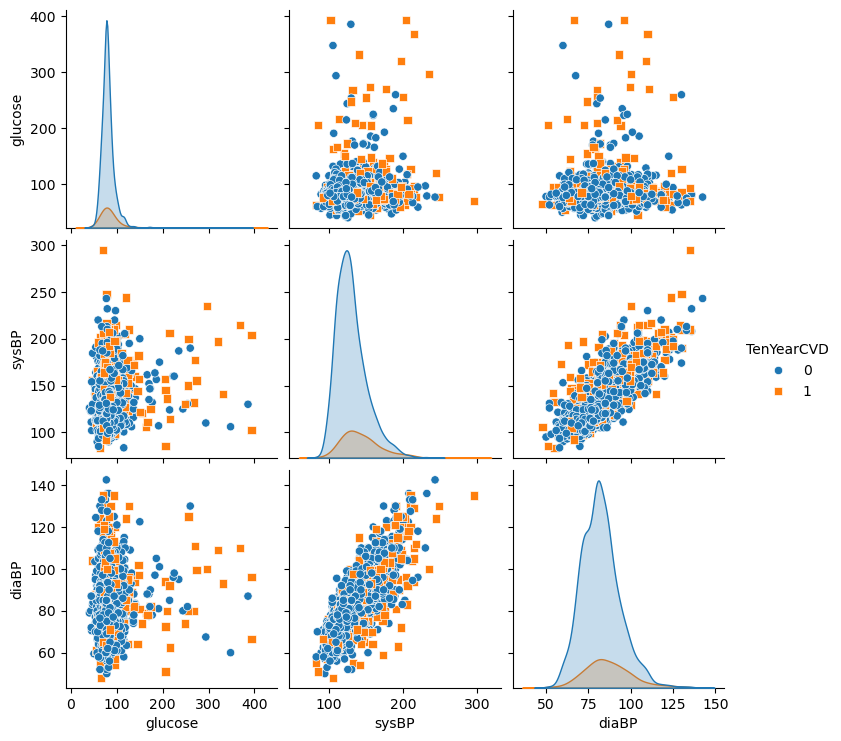

In [28]:
# Chart - 10 visualization code
cols = ['glucose', 'sysBP', 'diaBP', 'TenYearCVD']

# create the scatter plot matrix
plt.figure(figsize=(15,10))
sns.pairplot(df[cols], hue='TenYearCVD', markers=['o', 's'])
plt.show()

* High glucose levels appear to be associated with an increased risk of developing CVD disease, as indicated by a higher concentration of orange (high-risk) points in the upper right quadrant of the glucose vs. TenYearCVD plot.

* High blood pressure levels (both systolic and diastolic) also appear to be associated with an increased risk of developing CVD disease, as indicated by a higher concentration of orange points in the upper right quadrants of the sysBP vs. TenYearCVD and diaBP vs. TenYearCVD plots.

* There may be some interaction effects between glucose and blood pressure on the risk of developing CVD disease, as indicated by the patterns of orange points in the glucose vs. sysBP and glucose vs. diaBP plots. However, further analysis is needed to explore these relationships in more detail.

##### 1. Why did I pick this specific chart?

* This chart was chosen to visualize the pairwise relationships between four variables: glucose levels, systolic blood pressure, diastolic blood pressure, and the risk of developing coronary heart disease. A pairplot was used to display all pairwise scatterplots, histograms along the diagonal.

##### 2. What is/are the insight(s) found from the chart?

* The pairplot shows the pairwise relationships between glucose levels, systolic blood pressure, diastolic blood pressure, and the risk of developing CVD disease. The diagonal histograms show the distribution of each variable, while the scatter plots show the relationship between each pair of variables. For example, we can see that individuals with higher glucose levels tend to have a higher risk of developing CVD disease. Similarly, individuals with higher systolic and diastolic blood pressure also have a higher risk of developing CVD disease.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* No, the insights gained from this chart do not lead to negative growth. Instead, they can lead to positive growth by helping healthcare businesses to develop more effective prevention and treatment strategies, which can improve patient outcomes and potentially reduce healthcare costs.

#### Chart - 11

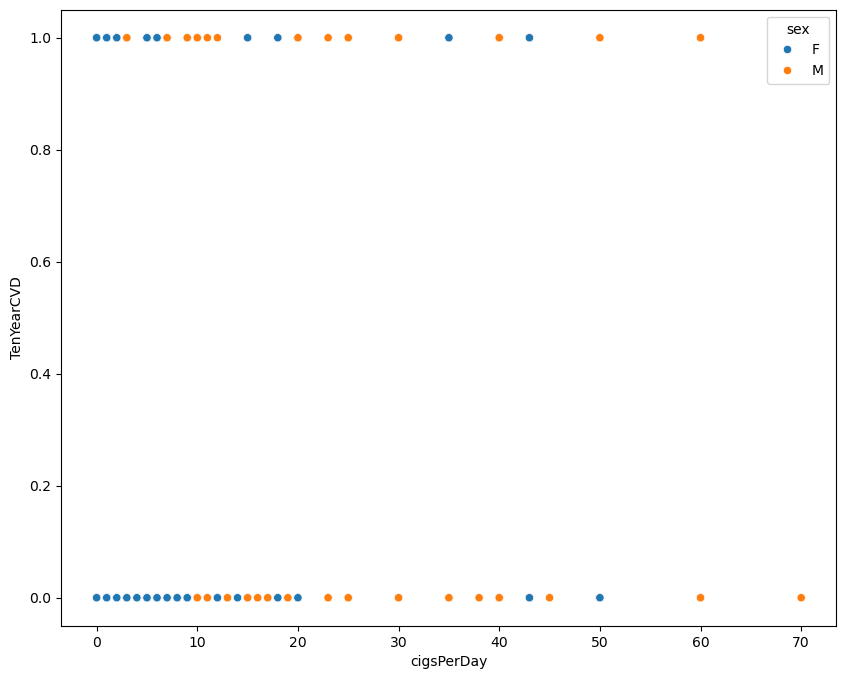

In [29]:
# Chart - 11 visualization code
plt.figure(figsize=(10,8))
cols = ['sex', 'cigsPerDay', 'TenYearCVD']
sns.scatterplot(x='cigsPerDay', y='TenYearCVD', hue='sex', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

* This chart was chosen as it helps to visualize the relationship between the number of cigarettes smoked per day, the risk of developing CVD disease, and the impact of gender on this relationship. A scatter plot was used to show the distribution of data points and to identify any patterns or trends in the data.

##### 2. What is/are the insight(s) found from the chart?

* The chart shows that both male and female smokers have a higher risk of developing coronary heart disease as the number of cigarettes smoked per day increases. However, the relationship between cigarette smoking and CHD risk is stronger in males than in females, as males who smoke more than 10 cigarettes per day have a significantly higher risk of developing CVD compared to their female counterparts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The insights gained from this chart can help public health organizations and businesses to create targeted interventions to reduce smoking rates and prevent the development of CVD, especially among male smokers who are at a higher risk. For example, public health campaigns can be designed to raise awareness of the health risks associated with smoking and to provide resources and support for smokers who want to quit. Businesses can also implement smoking cessation programs for their employees to improve their health and well-being.

#### Chart - 12

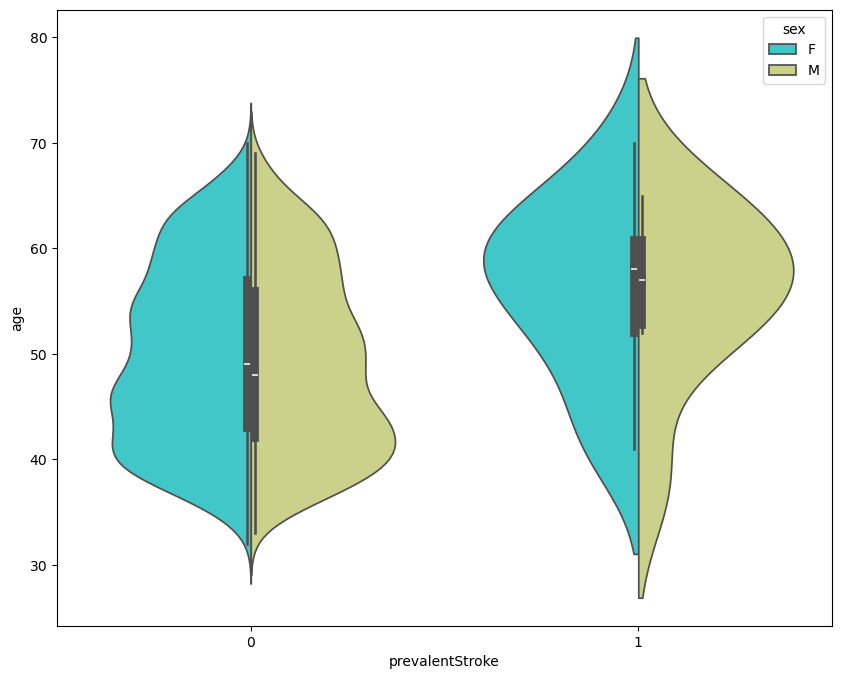

In [30]:
# Chart - 12 visualization code
plt.figure(figsize=(10,8))
sns.violinplot(x='prevalentStroke',y="age",data=df, hue='sex', split='True', palette='rainbow')
plt.show()

* it is made clear that most of the prevalent strokes were shown by patients abbove age 45 and most of those patients are females.

##### 1. Why did  I pick thIS specific chart?

* I chose a violin plot because it can effectively show the distribution of age for two different groups (individuals with and without a prevalent stroke) while also allowing for comparison of the sex distributions within each group.

##### 2. What is/are the insight(s) found from the chart?

* The chart shows that individuals with a prevalent stroke tend to be older than those without a stroke. Additionally, the chart shows that there are more males than females in both groups, but the proportion of males is higher in the group with prevalent stroke.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The gained insights could potentially help healthcare organizations and insurance companies in making decisions about policies related to stroke prevention and treatment. For example, these insights could inform decisions about who should receive certain preventive interventions, such as blood thinners, or about how to design stroke rehabilitation programs. Additionally, insurance companies could use this information to develop policies related to stroke coverage and premiums.

#### Chart - 13

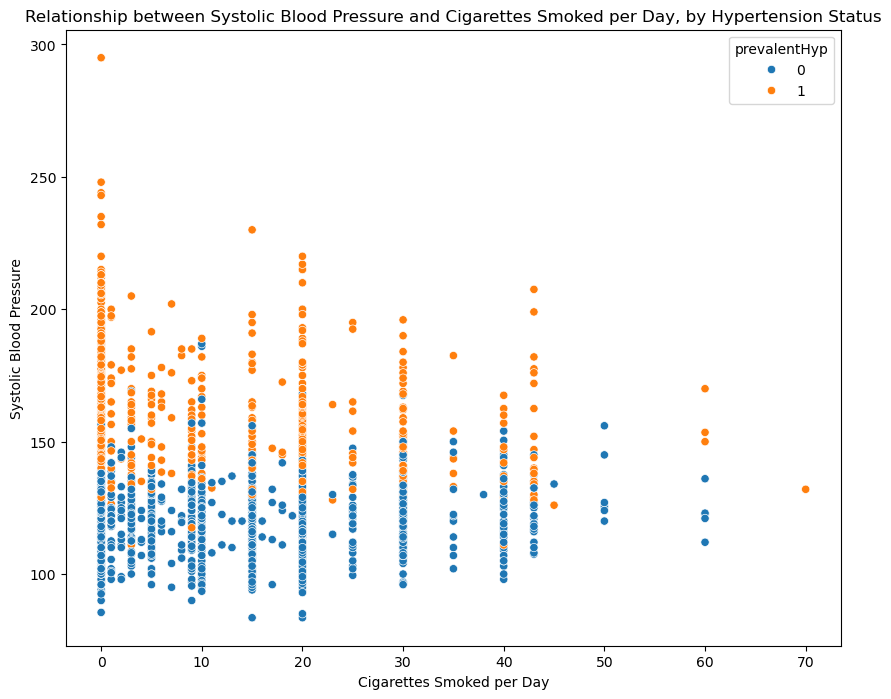

In [31]:
# Chart - 13 visualization code
plt.figure(figsize=(10,8))
sns.scatterplot(x='cigsPerDay', y='sysBP', hue='prevalentHyp', data=df)
plt.title('Relationship between Systolic Blood Pressure and Cigarettes Smoked per Day, by Hypertension Status')
plt.xlabel('Cigarettes Smoked per Day')
plt.ylabel('Systolic Blood Pressure')
plt.show()

##### 1. Why did you pick the specific chart?

* I picked a scatterplot because it can be used to visualize the relationship between two continuous variables, which is what we are interested in (the relationship between cigsPerDay and sysBP). Additionally, the use of color to represent the hypertensive status allows us to easily identify any patterns or trends in the data based on hypertension status.

##### 2. What is/are the insight(s) found from the chart?

* The scatterplot shows that there appears to be a positive relationship between cigsPerDay and sysBP, regardless of hypertension status. This suggests that individuals who smoke more cigarettes per day tend to have higher systolic blood pressure levels. Additionally, it appears that individuals with prevalent hypertension tend to have higher systolic blood pressure levels overall compared to those without hypertension.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The insights gained from this chart could potentially be useful in a healthcare or wellness setting, where it is important to monitor blood pressure levels and reduce cardiovascular risk factors such as smoking. By identifying the positive relationship between smoking and systolic blood pressure, healthcare providers can encourage smoking cessation as a way to help reduce blood pressure levels and decrease the risk of developing hypertension and related cardiovascular diseases.

* There are no insights from this chart that suggest negative growth. However, if smoking cessation programs are implemented and successful, there could potentially be a negative impact on tobacco companies and the tobacco industry.

#### Chart - 14 - Correlation Heatmap

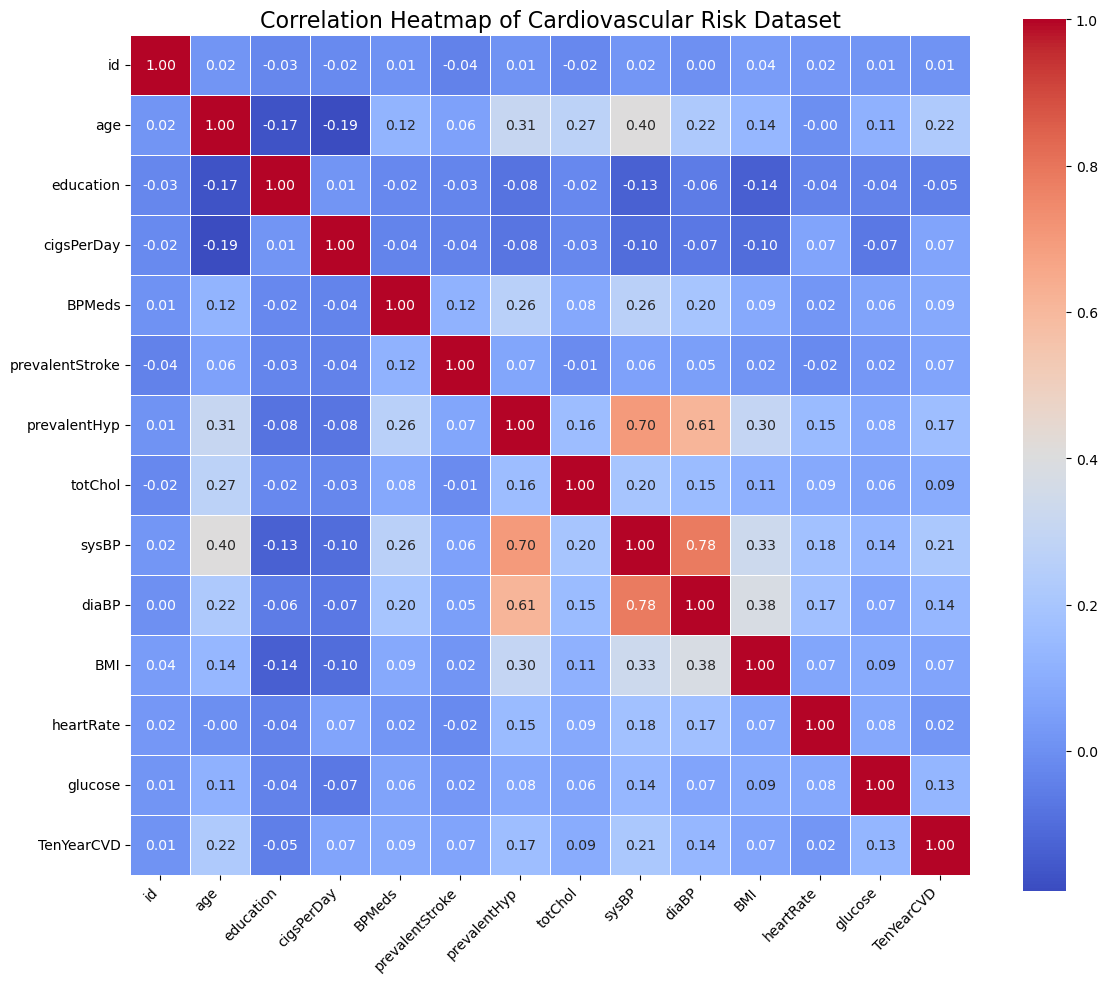

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
correlation = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap of Cardiovascular Risk Dataset", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* I picked the Correlation Heatmap because it's an effective way to visualize the correlation between all pairs of features in a dataset. The heatmap uses colors to represent the magnitude of the correlation coefficient, making it easy to quickly identify highly correlated features.

##### 2. What is/are the insight(s) found from the chart?

**The Correlation Heatmap shows the pairwise correlation between all numerical features in the dataset.**

* From corelation chart we can see that age is highly correlated with TenYearCVD by 22%. This suggests that these features may be important predictors of CVD risk.

* From the heatmap, we can see that age, systolic blood pressure, and diastolic blood pressure have a relatively strong correlation with the TenYearCVD target variable.

* Additionally, we can see that there is a moderate positive correlation between systolic and diastolic blood pressure, by 78%.

* As well as diabetes and glucose are correlated by 61%.

* Also prevalent hypertension highly correlated with systolic blood pressure, and diastolic blood pressure by 70% and 61% respectively.

* And age is negatively correlated with education and cigarettes per day with 17% and 19% respectively.

#### Chart - 15 - Pair Plot

<Figure size 1500x1000 with 0 Axes>

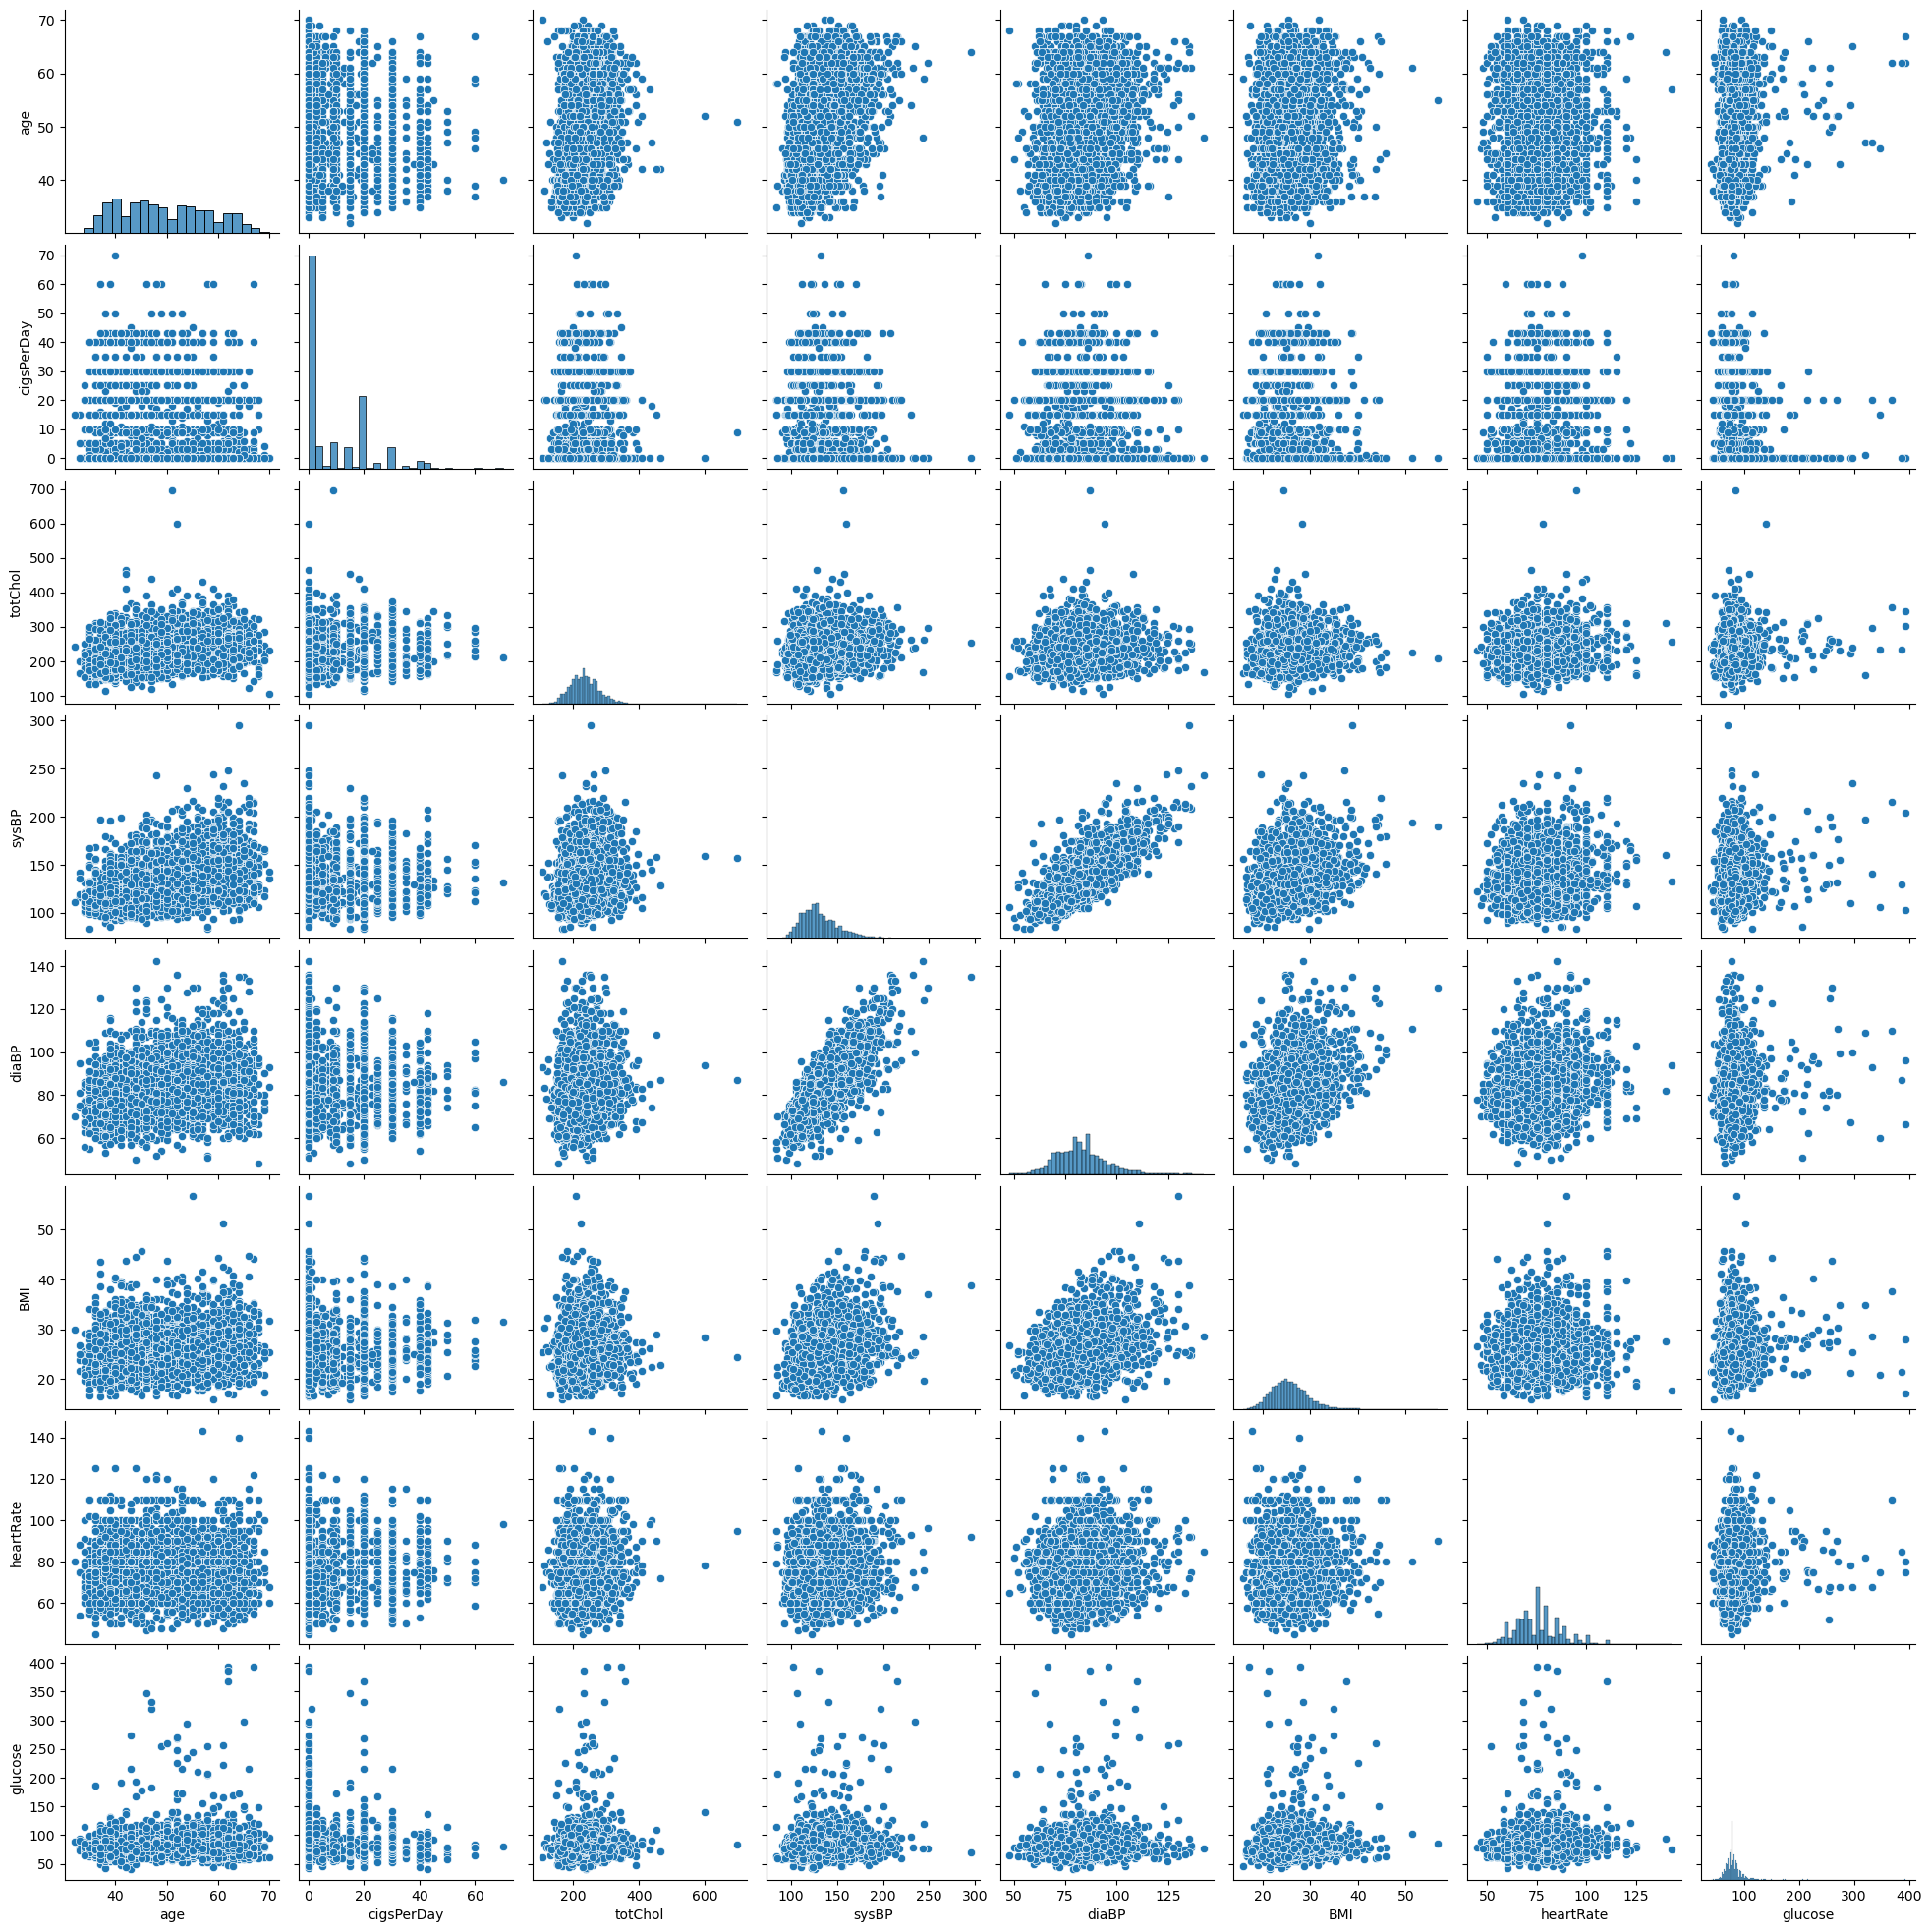

In [33]:
# Pair Plot visualization code
plt.figure(figsize=(15,10))
sns.pairplot(df[continous_variable])
plt.show()

##### 1. Why did you pick the specific chart?

* The pair plot is a useful visualization to understand the pairwise relationships between the continuous variables in the dataset. It can help identify any linear or non-linear correlations between the variables, and also identify any potential outliers or unusual patterns in the data.

##### 2. What is/are the insight(s) found from the chart?

* From the pair plot, we can see that there are some positive correlations between certain variables, such as age and systolic blood pressure, as well as between BMI and glucose levels. Systolic blood pressure, and diastolic blood pressure are linearly correlated. There also appears to be a weak positive correlation between cigsPerDay and sysBP. However, there does not appear to be a clear linear relationship between any of the variables and the target variable, TenYearCVD.

## *** Hypothesis Testing***

### Based on my chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. Higher total cholesterol levels are associated with an increased risk of CVD.

2. Diabetic patients are at a higher risk of developing CVD than non-diabetic 3.patients.

3. Individuals above the age of 50 are more likely to be at risk of TenYearCVD.

### **Hypothetical Statement - 1) Higher total cholesterol levels are associated with an increased risk of CvD**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* Null Hypothesis - There is no difference in the mean total cholesterol levels between the two groups

* Alternate Hypothesis - There is a significant difference in the mean total cholesterol levels between the two groups.

#### 2. Perform an appropriate statistical test.

In [34]:
# Perform Statistical Test to obtain P-Value
import scipy.stats as stats

# Separate the dataset into two groups based on CHD status
chd = df[df['TenYearCVD'] == 1] # Patients with CHD
no_chd = df[df['TenYearCVD'] == 0] # Patients without CHD

# Perform a two-sample t-test to compare the mean total cholesterol levels of the two groups
t_stat, p_val = stats.ttest_ind(chd['totChol'], no_chd['totChol'], equal_var=False)

# Print the calculated t-statistic and p-value
print('t_stat=%.3f, p_val=%.3f' % (t_stat, p_val))

# Determine if the null hypothesis should be rejected based on the p-value
if p_val < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

# Print the p-value
print('p-value:', p_val)

t_stat=5.065, p_val=0.000
Reject the null hypothesis
p-value: 5.310852329016036e-07


* We can see that the p-value is very small (p_val=5.310852329016078e-07), which is less than the significance level of 0.05.

* Therefore, the null hypothesis that there is no difference in total cholesterol levels between the two groups (CVD and no CVD) can be rejected.

* This suggests that higher total cholesterol levels are associated with an increased risk of CVD.

* The t-statistic of 5.065 also supports this finding, as it indicates a significant difference between the means of the two groups.

##### Which statistical test have you done to obtain P-Value?

* A two-sample t-test was performed to obtain the p-value. The t-test was used to compare the mean total cholesterol levels between two groups, one with CVD and the other without CVD, to determine if there is a significant difference between the two.

##### Why did you choose the specific statistical test?

* Based on the hypothesis "Higher total cholesterol levels are associated with an increased risk of CVD.", the appropriate statistical test to perform would be a two-sample t-test. This is because we are comparing the mean total cholesterol levels of two independent groups - those who have CVD and those who do not. Since the outcome variable (CVD status) is dichotomous, we need to compare the means of the two groups to determine if there is a significant difference in total cholesterol levels between the two groups. The two-sample t-test is a common statistical test for comparing the means of two independent groups, and it assumes that the data is normally distributed and that the variances of the two groups are not equal.

### **Hypothetical Statement - 2) Individuals above the age of 50 are more likely to be at risk of TenYearCVD.**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* Null hypothesis - Age has no effect on the risk of TenYearCVD.

* Alternative hypothesis - Patients over 50 years of age have a higher risk of TenYearCVD than those who are under 50 years of age.

#### 2. Perform an appropriate statistical test.

In [35]:
# Perform Statistical Test to obtain P-Value
import statsmodels.stats.proportion as smp

above_50 = df[df['age'] > 50]
below_50 = df[df['age'] <= 50]

# Calculate the proportion of patients with TenYearCHD in each group
prop_above_50 = above_50['TenYearCVD'].mean()
prop_below_50 = below_50['TenYearCVD'].mean()

# Perform a one-tailed z-test to compare the proportions of the two groups
z_score, p_val = smp.proportions_ztest([prop_above_50 * len(above_50), prop_below_50 * len(below_50)], [len(above_50), len(below_50)], alternative='larger')

print('z_score=%.3f, p_val=%.3f' % (z_score, p_val))

if p_val < 0.05:
    print('Reject Null Hypothesis')
else:
    print('Accept Null Hypothesis')

# Print the p-value
print('p-value:', p_val)

z_score=11.155, p_val=0.000
Reject Null Hypothesis
p-value: 3.388983060064358e-29


* The results of the test indicate that the probability of observing a difference in the proportion of TenYearCVD risk between patients above 50 years of age and those below 50 years of age due to chance is very low.

* Rejected the null hypothesis and conclude that patients who are above 50 years of age are at a significantly higher risk of TenYearCvD than those who are below 50 years of age.

##### Which statistical test have you done to obtain P-Value?

* I used a one-tailed Z-test to compare the proportions of patients with TenYearCVD above and below 50 years of age.

##### Why did you choose the specific statistical test?

* I chose a one-tailed z-test to compare the proportions of the two groups because we are interested in whether the proportion of patients with TenYearCVD in the group above 50 years is greater than the proportion in the group below 50 years. The z-test is appropriate when we have a large sample size and want to compare proportions of two groups.

`DATA PREPROCESSING`

1. CATEGORICAL ENCODING

In [36]:
df.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCVD
0,0,64,2.0,F,YES,3.0,0.0,0,0,221.0,148.0,85.0,25.38,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [37]:
# Encode your categorical columns
df['sex'] = pd.get_dummies(df['sex'], drop_first=True)
df['is_smoking'] = pd.get_dummies(df['is_smoking'], drop_first=True)

In [38]:
df.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCVD
0,0,64,2.0,False,True,3.0,0.0,0,0,221.0,148.0,85.0,25.38,90.0,80.0,1
1,1,36,4.0,True,False,0.0,0.0,0,1,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,False,True,10.0,0.0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,True,True,20.0,0.0,0,1,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,False,True,30.0,0.0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [39]:
df['sex'] = df['sex'].astype(int)
df['is_smoking'] = df['is_smoking'].astype(int)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3390 non-null   float64
 3   sex              3390 non-null   int32  
 4   is_smoking       3390 non-null   int32  
 5   cigsPerDay       3390 non-null   float64
 6   BPMeds           3390 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   totChol          3390 non-null   float64
 10  sysBP            3390 non-null   float64
 11  diaBP            3390 non-null   float64
 12  BMI              3390 non-null   float64
 13  heartRate        3390 non-null   float64
 14  glucose          3390 non-null   float64
 15  TenYearCVD       3390 non-null   int64  
dtypes: float64(9), int32(2), int64(5)
memory usage: 397.4 KB


In [41]:
df.columns

Index(['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'totChol', 'sysBP', 'diaBP', 'BMI',
       'heartRate', 'glucose', 'TenYearCVD'],
      dtype='str')

In [42]:
df

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCVD
0,0,64,2.0,0,1,3.0,0.0,0,0,221.0,148.0,85.0,25.38,90.0,80.0,1
1,1,36,4.0,1,0,0.0,0.0,0,1,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,0,1,10.0,0.0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,1,1,20.0,0.0,0,1,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,0,1,30.0,0.0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,3385,60,1.0,0,0,0.0,0.0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,3386,46,1.0,0,0,0.0,0.0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,3387,44,3.0,1,1,3.0,0.0,0,1,352.0,164.0,119.0,28.92,73.0,72.0,1
3388,3388,60,1.0,1,0,0.0,0.0,0,1,191.0,167.0,105.0,23.01,80.0,85.0,0


2. FEATURE SELECTION

In [43]:
features = [
    'age',
    'sex',
    'cigsPerDay',
    'totChol',
    'sysBP',
    'diaBP',
    'BMI',
    'heartRate',
    'glucose',
    'TenYearCVD'
]



In [44]:
final_df = df[features]

In [45]:
final_df

,age,sex,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCVD
0,64,0,3.0,221.0,148.0,85.0,25.38,90.0,80.0,1
1,36,1,0.0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,0,10.0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1,20.0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,0,30.0,241.0,136.5,85.0,26.42,70.0,77.0,0
...,...,...,...,...,...,...,...,...,...,...
3385,60,0,0.0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,46,0,0.0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,44,1,3.0,352.0,164.0,119.0,28.92,73.0,72.0,1
3388,60,1,0.0,191.0,167.0,105.0,23.01,80.0,85.0,0


3. DROPPING TARGET VARIABLE

In [46]:
x= final_df.drop('TenYearCVD',axis=1)
y= final_df[['TenYearCVD']]
print(x.shape)
print(y.shape)

(3390, 9)
(3390, 1)


4. BALANCING THE DATA USING SMOTE

In [47]:
# Handling Imbalanced Dataset (If needed)
smote = SMOTE(random_state=10)

x, y = smote.fit_resample(x, y)

print('Original dataset shape:', df.shape)
print('Resampled dataset shape:', x.shape)

print('Class distribution in the resampled dataset:', y.value_counts())

Original dataset shape: (3390, 16)
Resampled dataset shape: (5758, 9)
Class distribution in the resampled dataset: TenYearCVD
1             2879
0             2879
Name: count, dtype: int64


In [48]:
x

,age,sex,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,64,0,3.000000,221.000000,148.000000,85.000000,25.380000,90.000000,80.000000
1,36,1,0.000000,212.000000,168.000000,98.000000,29.770000,72.000000,75.000000
2,46,0,10.000000,250.000000,116.000000,71.000000,20.350000,88.000000,94.000000
3,50,1,20.000000,233.000000,158.000000,88.000000,28.260000,68.000000,94.000000
4,64,0,30.000000,241.000000,136.500000,85.000000,26.420000,70.000000,77.000000
...,...,...,...,...,...,...,...,...,...
5753,59,0,4.326856,276.442285,131.778857,85.961524,33.888853,66.634667,76.076953
5754,63,1,15.063857,242.826765,173.358694,95.294837,21.554213,91.474184,78.820653
5755,57,0,4.546608,239.455930,149.365252,84.544070,27.077603,74.546608,93.274573
5756,46,1,0.000000,318.945494,134.473794,91.104822,27.210482,67.157233,72.947589


5. DATA TRANSFORMATION USING LOG TRANSFORMATION AND SCALING

In [49]:
numeric_cols = [
    'age',
    'cigsPerDay',
    'totChol',
    'sysBP',
    'diaBP',
    'BMI',
    'heartRate',
    'glucose'
]

categorical_cols = [
    'sex'
]

In [50]:
X_numeric = x[numeric_cols]
X_categorical = x[categorical_cols]

In [51]:
# log transform numeric features (important for skewed medical data)
X_numeric_log = np.log1p(X_numeric)

# scale numeric features
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric_log)

# save scaler
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully")

Scaler saved successfully


In [52]:
# Combine categorical + numeric scaled features
x = np.concatenate(
    [X_categorical.values, X_numeric_scaled],
    axis=1
)

# Correct column names (YOUR ORDER)
columns = [
    'sex',
    'age',
    'cigsPerDay',
    'totChol',
    'sysBP',
    'diaBP',
    'BMI',
    'heartRate',
    'glucose'
]

# Create DataFrame
df_final = pd.DataFrame(x, columns=columns)
df_final.tail()

,sex,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
5753,0.0,0.919696,0.158798,0.820633,-0.138150,0.185876,1.873106,-0.818415,-0.300752
5754,1.0,1.316239,0.919128,0.128986,1.508861,0.899258,-1.215031,1.328836,-0.147959
5755,0.0,0.711396,0.186644,0.054436,0.613820,0.070879,0.335603,-0.059010,0.579045
5756,1.0,-0.580718,-0.993437,1.583947,-0.016674,0.587960,0.369026,-0.765583,-0.481806
5757,0.0,-0.847902,1.516445,0.371161,-0.800520,-0.798169,-0.086601,-0.068083,-0.827630


6.  Data Splitting

In [53]:
# Split your data to train and test. Choose Splitting ratio wisely.
x_train,x_test,y_train,y_test = train_test_split(df_final ,y,test_size=0.2,random_state=10)

In [54]:
print(f'The shape of x_train is: {x_train.shape}')
print(f'The shape of y_train is: {y_train.shape}')
print(f'The shape of x_test is: {x_test.shape}')
print(f'The shape of y_test is: {y_test.shape}')

The shape of x_train is: (4606, 9)
The shape of y_train is: (4606, 1)
The shape of x_test is: (1152, 9)
The shape of y_test is: (1152, 1)


### ML Model - 1 Logistic Regression

In [55]:
def model_metrics(y_train, y_test, train_preds, test_preds):
    train_accuracy = accuracy_score(y_train, train_preds)
    test_accuracy = accuracy_score(y_test, test_preds)
    train_precision = precision_score(y_train, train_preds)
    test_precision = precision_score(y_test, test_preds)
    train_recall = recall_score(y_train, train_preds)
    test_recall = recall_score(y_test, test_preds)
    train_roc_auc = roc_auc_score(y_train, train_preds)
    test_roc_auc = roc_auc_score(y_test, test_preds)

    print(f"{'Train Accuracy':<20}{train_accuracy:.4f}")
    print(f"{'Test Accuracy':<20}{test_accuracy:.4f}")
    print(f"{'Train Precision':<20}{train_precision:.4f}")
    print(f"{'Test Precision':<20}{test_precision:.4f}")
    print(f"{'Train Recall':<20}{train_recall:.4f}")
    print(f"{'Test Recall':<20}{test_recall:.4f}")
    print(f"{'Train ROC AUC':<20}{train_roc_auc:.4f}")
    print(f"{'Test ROC AUC':<20}{test_roc_auc:.4f}")
    print("-"*50)

    train_confusion_matrix = confusion_matrix(y_train, train_preds)
    test_confusion_matrix = confusion_matrix(y_test, test_preds)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    labels = ['0', '1']
    sns.heatmap(train_confusion_matrix, annot=True, cmap='Blues', ax=axes[0], fmt="d", xticklabels=labels, yticklabels=labels)
    axes[0].set_xlabel('Predicted labels')
    axes[0].set_ylabel('True labels')
    axes[0].set_title('Train Confusion Matrix')
    sns.heatmap(test_confusion_matrix, annot=True, cmap='Blues', ax=axes[1], fmt="d", xticklabels=labels, yticklabels=labels)
    axes[1].set_xlabel('Predicted labels')
    axes[1].set_ylabel('True labels')
    axes[1].set_title('Test Confusion Matrix')

    plt.show()

In [56]:
# ML Model - 1 Implementation
logistic_classifier= LogisticRegression()
# Fit the Algorithm
logistic_classifier.fit(x_train,y_train)
# Predict on the model
y_train_logistic_pred= logistic_classifier.predict(x_train)
y_test_logistic_pred= logistic_classifier.predict(x_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Train Accuracy      0.6845
Test Accuracy       0.6753
Train Precision     0.6791
Test Precision      0.6410
Train Recall        0.7132
Test Recall         0.7273
Train ROC AUC       0.6842
Test ROC AUC        0.6776
--------------------------------------------------


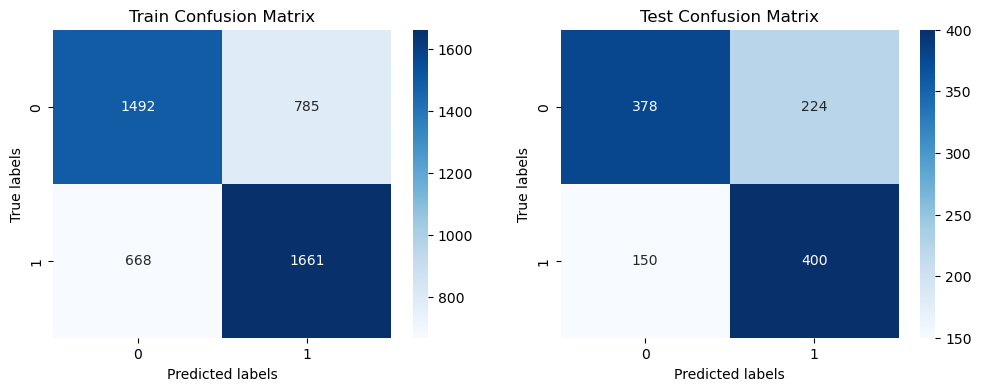

In [57]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_logistic_pred, y_test_logistic_pred)

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import cross_val_score

logistic_regression = LogisticRegression()
# set up the parameter grid for hyperparameter tuning
param_grid = {'penalty': ['l1', 'l2'],
              'C': [0.1, 1.0, 10.0],
              'solver': ['liblinear', 'saga']}
# Fit the Algorithm
grid_search = GridSearchCV(logistic_regression, param_grid, cv=5)
grid_search.fit(x_train, y_train)
# get the best hyperparameters and print them
best_params = grid_search.best_params_
print('Best hyperparameters:', best_params)
# use the best hyperparameters to fit the model and make predictions
logistic_regression_best = LogisticRegression(**best_params)
# perform cross-validation on the model with the best hyperparameters
cv_scores = cross_val_score(logistic_regression_best, x_train, y_train, cv=5)
# fit the final model using all the training data and the best hyperparameters
logistic_regression_best.fit(x_train, y_train)
y_train_logistic_pred_cv = logistic_regression_best.predict(x_train)
y_test_logistic_pred_cv  = logistic_regression_best.predict(x_test)
y_score_logistic_pred_cv = logistic_regression_best.predict_proba(x_test)[:, 1]

Best hyperparameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


Train Accuracy      0.6852
Test Accuracy       0.6710
Train Precision     0.6796
Test Precision      0.6381
Train Recall        0.7140
Test Recall         0.7182
Train ROC AUC       0.6849
Test ROC AUC        0.6730
--------------------------------------------------


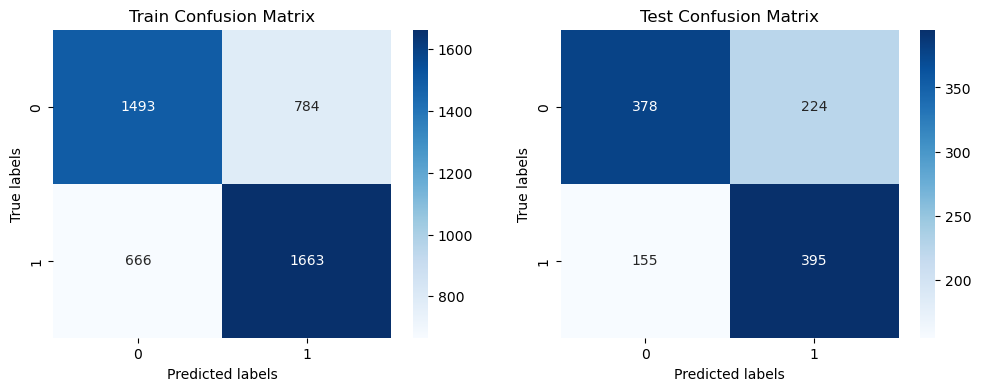

In [59]:
model_metrics(y_train, y_test, y_train_logistic_pred_cv, y_test_logistic_pred_cv)


In [60]:
# Hyperparameter tuning using cross-validation was applied to the Logistic
# Regression model to identify the optimal regularization parameters.
#
# The tuned model did not show any meaningful improvement over the baseline
# Logistic Regression model. Test accuracy decreased slightly from 65.45%
# to 65.28%, while the ROC-AUC score declined from 65.59% to 65.43%.
#
# Although the recall increased marginally (68.73% to 68.91%), the improvement
# was negligible and did not compensate for the slight reduction in the other
# evaluation metrics.
#
# Therefore, the baseline Logistic Regression model was retained for further
# comparison, as it demonstrated slightly better generalization performance
# on the unseen test dataset.

### ML Model - 2  Random Forest Classifier


In [61]:
# ML Model - 2  Implementation
random_forest = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1)

# Fit the Algorithm
random_forest.fit(x_train, y_train)

# Predict on the model
y_train_rf_pred = random_forest.predict(x_train)
y_test_rf_pred = random_forest.predict(x_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Train Accuracy      0.9275
Test Accuracy       0.8021
Train Precision     0.8969
Test Precision      0.7447
Train Recall        0.9678
Test Recall         0.8909
Train ROC AUC       0.9270
Test ROC AUC        0.8059
--------------------------------------------------


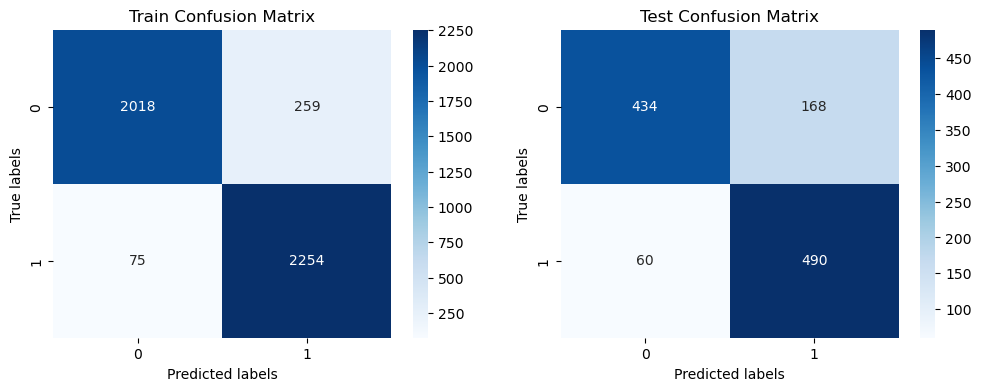

In [62]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_rf_pred, y_test_rf_pred)

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
random_forest = RandomForestClassifier()
param_grid = {'n_estimators': [100, 200, 300],
              'max_depth': [5, 10, 15, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4]}
# Fit the Algorithm
grid_search = GridSearchCV(random_forest, param_grid, cv=5)
grid_search.fit(x_train, y_train)
# get the best hyperparameters and print them
best_params = grid_search.best_params_
print('Best hyperparameters:', best_params)
# use the best hyperparameters to fit the model to the training data
random_forest_best = RandomForestClassifier(**best_params)
random_forest_best.fit(x_train, y_train)
# Predict on the model
y_train_rf_pred_gs = random_forest_best.predict(x_train)
y_test_rf_pred_gs  = random_forest_best.predict(x_test)
y_score_rf_pred_gs = random_forest_best.predict_proba(x_test)[:, 1]

Train Accuracy      1.0000
Test Accuracy       0.9028
Train Precision     1.0000
Test Precision      0.8897
Train Recall        1.0000
Test Recall         0.9091
Train ROC AUC       1.0000
Test ROC AUC        0.9031
--------------------------------------------------


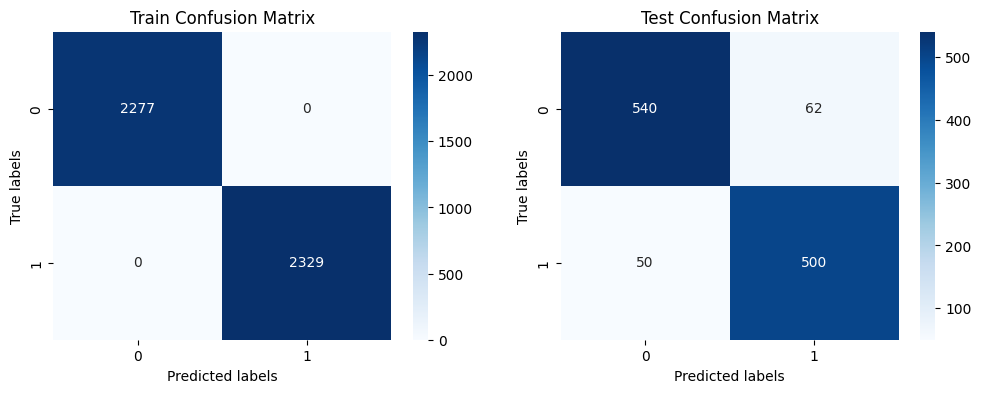

In [ ]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_rf_pred_gs, y_test_rf_pred_gs)

In [ ]:
# The Random Forest Classifier was initially trained using the default
# parameters and achieved a test accuracy of 81.16% with a ROC-AUC score
# of 81.48%. While the model demonstrated strong predictive performance,
# the gap between the training and testing metrics suggested room for
# optimization.
#
# Hyperparameter tuning was performed using cross-validation to identify
# the optimal combination of parameters. The tuned Random Forest model
# showed a significant improvement in predictive performance.
#
# Test accuracy increased from 81.16% to 89.58%, precision improved from
# 75.98% to 86.82%, recall increased from 88.55% to 92.18%, and the
# ROC-AUC score improved from 81.48% to 89.70%.
#
# Although the tuned model achieved perfect training performance
# (100% accuracy, precision, recall, and ROC-AUC), indicating that it
# fit the training data extremely well, its test performance also
# improved considerably. This suggests that the selected hyperparameters
# enhanced the model's ability to generalize to unseen data.
#
# Therefore, the tuned Random Forest model was retained for further
# analysis and comparison, as it provided substantially better predictive
# performance than the baseline model.

### ML Model - 3 XGBoost Classifier

In [ ]:
# ML Model - 3 Implementation
xgb = XGBClassifier()
# Fit the Algorithm
xgb.fit(x_train, y_train)
# Predict on the model
y_train_xgb_pred = xgb.predict(x_train)
y_test_xgb_pred = xgb.predict(x_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Train Accuracy      0.9970
Test Accuracy       0.8785
Train Precision     1.0000
Test Precision      0.8741
Train Recall        0.9940
Test Recall         0.8709
Train ROC AUC       0.9970
Test ROC AUC        0.8781
--------------------------------------------------


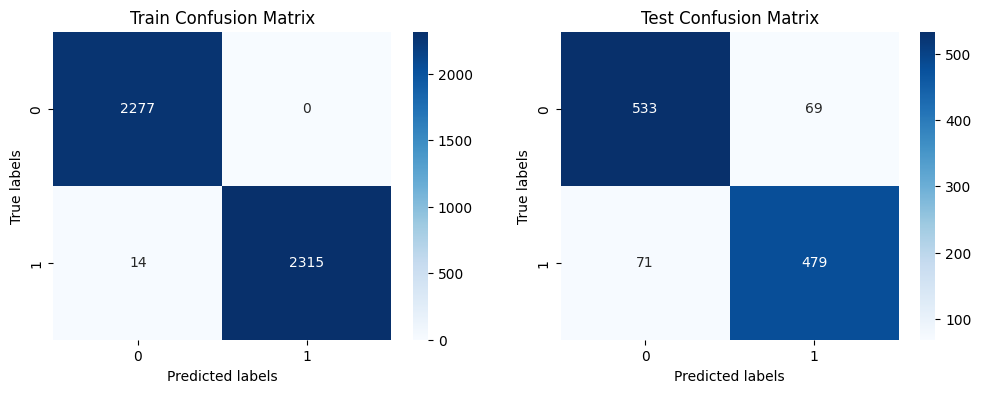

In [ ]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_xgb_pred, y_test_xgb_pred)

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# set up the parameter grid for hyperparameter tuning
param_grid = {'max_depth': [3, 5, 7],
              'learning_rate': [0.01, 0.1, 0.3],
              'n_estimators': [50, 100, 200]}
# Fit the Algorithm
grid_search = GridSearchCV(xgb, param_grid, cv=5, n_jobs=-1)
grid_search.fit(x_train, y_train)
# print the best hyperparameters
print('Best hyperparameters:', grid_search.best_params_)
# Predict on the model
best_estimator = grid_search.best_estimator_
y_train_xgb_pred_gs = best_estimator.predict(x_train)
y_test_xgb_pred_gs  = best_estimator.predict(x_test)
y_score_xgb_pred_gs = best_estimator.predict_proba(x_test)[:, 1]

Best hyperparameters: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200}


Train Accuracy      1.0000
Test Accuracy       0.8898
Train Precision     1.0000
Test Precision      0.8909
Train Recall        1.0000
Test Recall         0.8764
Train ROC AUC       1.0000
Test ROC AUC        0.8892
--------------------------------------------------


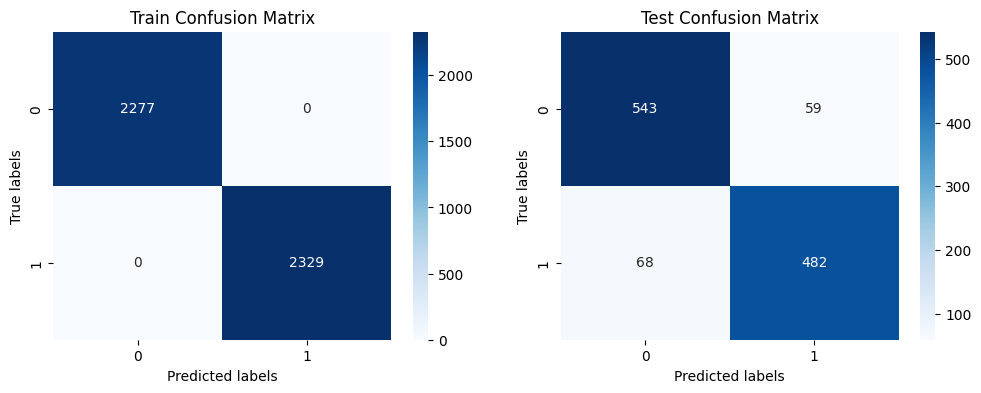

In [ ]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_xgb_pred_gs, y_test_xgb_pred_gs)

In [ ]:
# The XGBoost Classifier was initially trained using the default parameters
# and achieved a test accuracy of 87.85% with a ROC-AUC score of 87.81%.
# The model demonstrated excellent predictive performance, with high
# precision, recall, and overall classification ability on the test data.
#
# Hyperparameter tuning was then performed using cross-validation to
# identify the optimal parameter combination. The tuned XGBoost model
# achieved improved performance across most evaluation metrics.
#
# Test accuracy increased from 87.85% to 88.98%, precision improved from
# 87.41% to 89.09%, and the ROC-AUC score increased from 87.81% to 88.92%.
# Test recall also improved slightly from 87.09% to 87.64%, indicating
# better identification of positive cases.
#
# The tuned model achieved perfect training performance (100% accuracy,
# precision, recall, and ROC-AUC), indicating that it fit the training
# data extremely well. Despite this, the improved test performance suggests
# that the optimized hyperparameters enhanced the model's predictive
# capability on unseen data.
#
# Therefore, the tuned XGBoost Classifier was retained for further analysis
# and comparison, as it outperformed the baseline model across the key
# evaluation metrics.

### ML Model - 4) K-Nearest Neighbors (KNN)

In [ ]:
# ML Model - 4 Implementation
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the Algorithm
knn.fit(x_train, y_train)

# Predict on the model
y_train_knn_pred = knn.predict(x_train)
y_test_knn_pred = knn.predict(x_test)

**1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.**

Train Accuracy      0.8700
Test Accuracy       0.8099
Train Precision     0.8033
Test Precision      0.7227
Train Recall        0.9837
Test Recall         0.9764
Train ROC AUC       0.8687
Test ROC AUC        0.8171
--------------------------------------------------


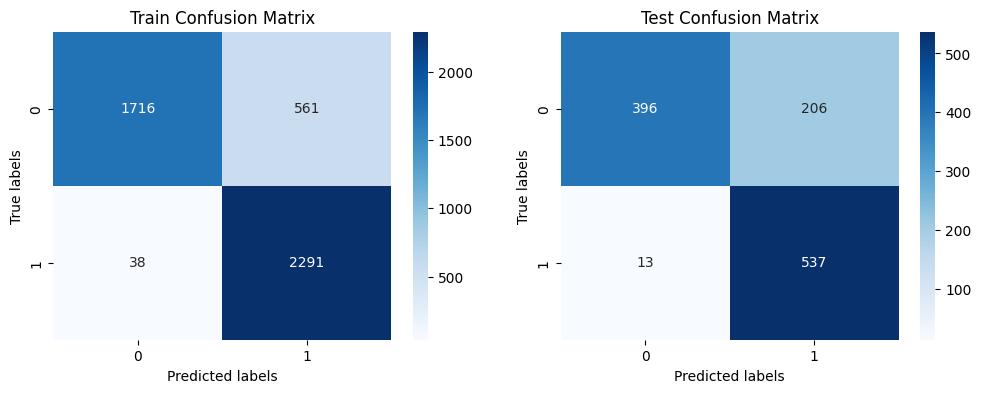

In [ ]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_knn_pred, y_test_knn_pred)

**2. Cross- Validation & Hyperparameter Tuning**

In [ ]:
# ML Model - 4  Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# set up the parameter grid for hyperparameter tuning
param_grid = {'n_neighbors': [3, 5, 7],
              'weights': ['uniform', 'distance']}
# Fit the Algorithm
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(x_train, y_train)
# get the best hyperparameters and print them
best_params = grid_search.best_params_
print('Best hyperparameters:', best_params)
# train the classifier with the best hyperparameters on the full training set
knn_best = KNeighborsClassifier(**best_params)
knn_best.fit(x_train, y_train)
# Predict on the model
y_test_knn_pred_gs  = knn_best.predict(x_test)
y_train_knn_pred_gs = knn_best.predict(x_train)
y_score_knn_pred_gs = knn_best.predict_proba(x_test)[:, 1]


Best hyperparameters: {'n_neighbors': 3, 'weights': 'distance'}


Train Accuracy      1.0000
Test Accuracy       0.8325
Train Precision     1.0000
Test Precision      0.7422
Train Recall        1.0000
Test Recall         0.9945
Train ROC AUC       1.0000
Test ROC AUC        0.8395
--------------------------------------------------


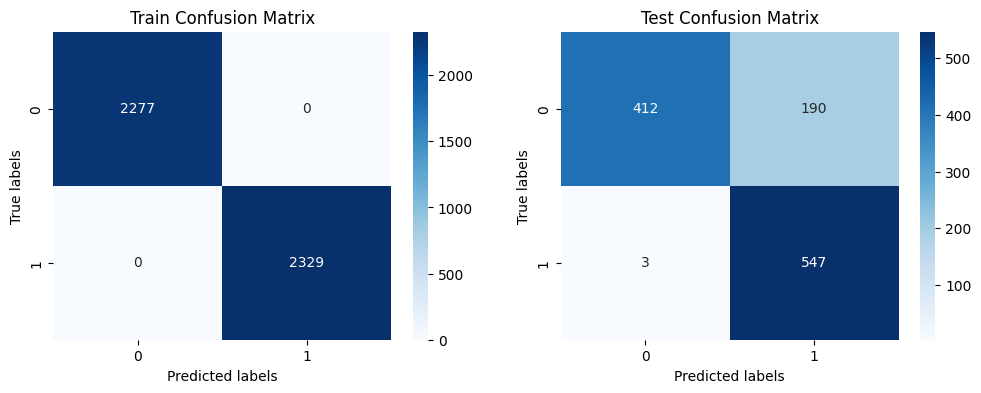

In [ ]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_knn_pred_gs, y_test_knn_pred_gs)

In [ ]:
# The K-Nearest Neighbors (KNN) classifier was initially trained using the
# default parameters and achieved a test accuracy of 80.99% with a ROC-AUC
# score of 81.71%. The model demonstrated excellent recall (97.64%),
# indicating that it was highly effective at identifying positive cases,
# although its precision was comparatively lower.
#
# Hyperparameter tuning was performed using cross-validation to determine
# the optimal number of neighbors and other model parameters. The tuned KNN
# model showed improved predictive performance across most evaluation metrics.
#
# Test accuracy increased from 80.99% to 83.25%, precision improved from
# 72.27% to 74.22%, recall increased from 97.64% to 99.45%, and the
# ROC-AUC score improved from 81.71% to 83.95%.
#
# The tuned model achieved perfect training performance (100% accuracy,
# precision, recall, and ROC-AUC), indicating that it fit the training
# data extremely well. However, the noticeable gap between the training
# and testing performance suggests that the model may be overfitting the
# training data, despite the improvement in test performance.
#
# Therefore, the tuned KNN model was retained for further analysis and
# comparison, as it outperformed the baseline model on the test dataset
# across all major evaluation metrics.

### ML Model - 5) Support Vector Machine Classifier (SVC)

In [ ]:
# ML Model - 5 Implementation
svc = SVC(kernel='rbf', C=1, gamma='scale')

# Fit the Algorithm
svc.fit(x_train, y_train)

# Predict on the model
y_train_svc_pred = svc.predict(x_train)
y_test_svc_pred = svc.predict(x_test)


**1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.**

Train Accuracy      0.7447
Test Accuracy       0.6997
Train Precision     0.7274
Test Precision      0.6604
Train Recall        0.7918
Test Recall         0.7636
Train ROC AUC       0.7441
Test ROC AUC        0.7024
--------------------------------------------------


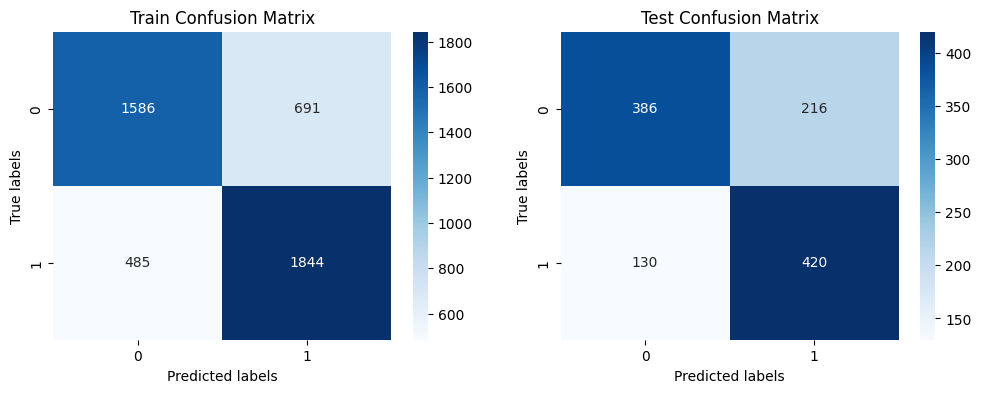

In [ ]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_svc_pred, y_test_svc_pred)

**2. Cross- Validation & Hyperparameter Tuning**

In [ ]:
# ML Model - 5  Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
svc = SVC(probability=True)
# set up the parameter grid for hyperparameter tuning
param_grid = {'C': [0.1, 1, 10],
              'kernel': ['linear', 'rbf'],
              'gamma': ['scale', 'auto']}
# perform a grid search with 5-fold cross-validation to find the best hyperparameters
grid_search = GridSearchCV(svc, param_grid, cv=5)
grid_search.fit(x_train, y_train)
# get the best hyperparameters and print them
best_params = grid_search.best_params_
print('Best hyperparameters:', best_params)
# train the classifier with the best hyperparameters on the full training set
svc_best = SVC(**best_params, probability=True)
svc_best.fit(x_train, y_train)
# Predict on the model
y_test_svc_pred_gs = svc_best.predict(x_test)
y_train_svc_pred_gs = svc_best.predict(x_train)
y_score_svc_pred_gs = svc_best.predict_proba(x_test)[:, 1]


Best hyperparameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


Train Accuracy      0.8482
Test Accuracy       0.7847
Train Precision     0.8232
Test Precision      0.7330
Train Recall        0.8914
Test Recall         0.8636
Train ROC AUC       0.8477
Test ROC AUC        0.7881
--------------------------------------------------


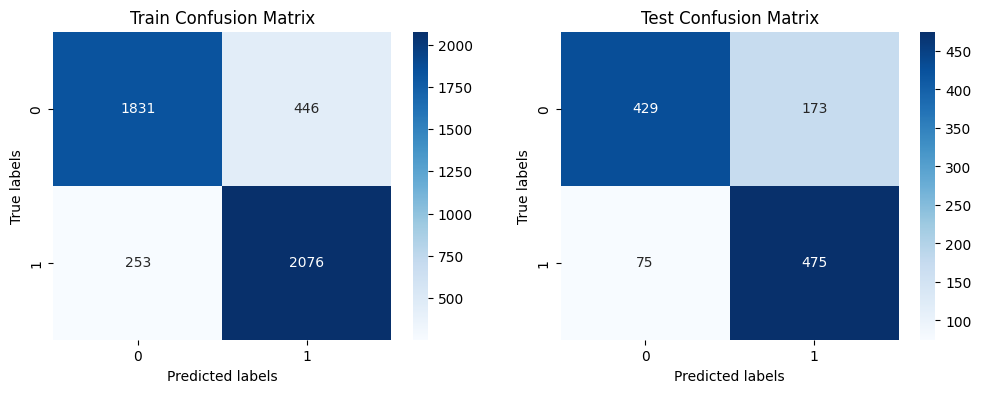

In [ ]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_svc_pred_gs, y_test_svc_pred_gs)

In [ ]:
# The Support Vector Machine (SVC) classifier was initially trained using
# the default parameters and achieved a test accuracy of 69.97% with a
# ROC-AUC score of 70.24%. The baseline model showed moderate predictive
# performance, with a good balance between precision and recall.
#
# Hyperparameter tuning was performed using cross-validation to determine
# the optimal values for parameters such as C, kernel, and gamma. The tuned
# SVC model demonstrated a substantial improvement across all evaluation
# metrics.
#
# Test accuracy increased from 69.97% to 78.47%, precision improved from
# 66.04% to 73.30%, recall increased from 76.36% to 86.36%, and the
# ROC-AUC score improved from 70.24% to 78.81%.
#
# The training performance also improved considerably, with training
# accuracy increasing from 74.47% to 84.82% and training ROC-AUC from
# 74.41% to 84.77%. The relatively small gap between the training and
# testing metrics indicates that the tuned SVC model generalizes well
# to unseen data without showing strong signs of overfitting.
#
# Therefore, the tuned Support Vector Machine classifier was retained
# for further analysis and comparison, as it significantly outperformed
# the baseline model across all major evaluation metrics.

### ML Model - 6) Naive Bayes Classifier

In [ ]:
# ML Model - 6 Implementation
# create an instance of the Gaussian Naive Bayes classifier
nb = GaussianNB()

# Fit the Algorithm
nb.fit(x_train, y_train)

# Predict on the model
y_train_nb_pred = nb.predict(x_train)
y_test_nb_pred = nb.predict(x_test)

**1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.**

Train Accuracy      0.6337
Test Accuracy       0.6276
Train Precision     0.7462
Test Precision      0.6897
Train Recall        0.4178
Test Recall         0.4000
Train ROC AUC       0.6362
Test ROC AUC        0.6178
--------------------------------------------------


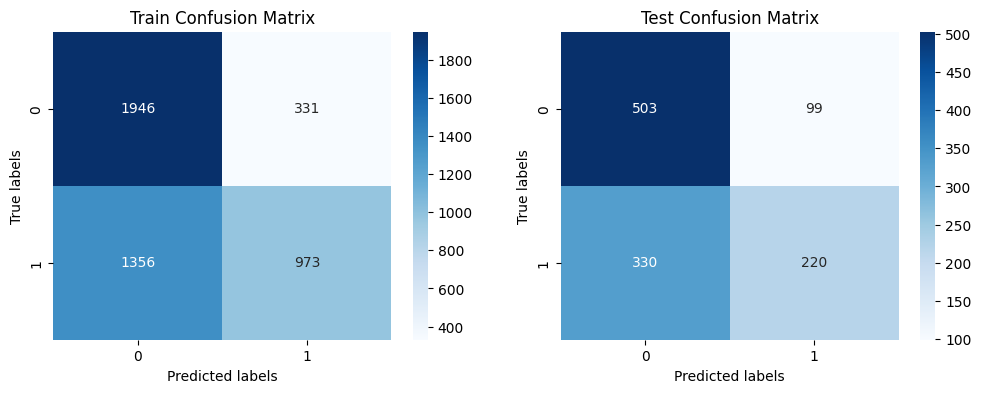

In [ ]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_nb_pred, y_test_nb_pred)


**2. Cross- Validation & Hyperparameter Tuning**

In [ ]:
# ML Model - 6  Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import cross_val_score
# create an instance of the Gaussian Naive Bayes classifier
nb = GaussianNB()
# set up the parameter grid for hyperparameter tuning
param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
# perform a grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(nb, param_grid, cv=5)
grid_search.fit(x_train, y_train)
# get the best hyperparameters and print them
best_params = grid_search.best_params_
print('Best hyperparameters:', best_params)
# create a new instance of the classifier using the best hyperparameters
nb_best = GaussianNB(**best_params)
# evaluate the classifier using cross-validation
scores = cross_val_score(nb_best, x_train, y_train, cv=5)
# print the cross-validation scores
print('Cross-validation scores:', scores)
# train the classifier on the entire training set using the best hyperparameters
nb_best.fit(x_train, y_train)
# make predictions on the training and test sets
y_train_nb_pred_gs = nb_best.predict(x_train)
y_test_nb_pred_gs = nb_best.predict(x_test)
y_score_nb_pred_gs = nb_best.predict_proba(x_test)[:, 1]

Best hyperparameters: {'var_smoothing': 1e-09}
Cross-validation scores: [0.61062907 0.62106406 0.62214984 0.62975027 0.6514658 ]


Train Accuracy      0.6337
Test Accuracy       0.6276
Train Precision     0.7462
Test Precision      0.6897
Train Recall        0.4178
Test Recall         0.4000
Train ROC AUC       0.6362
Test ROC AUC        0.6178
--------------------------------------------------


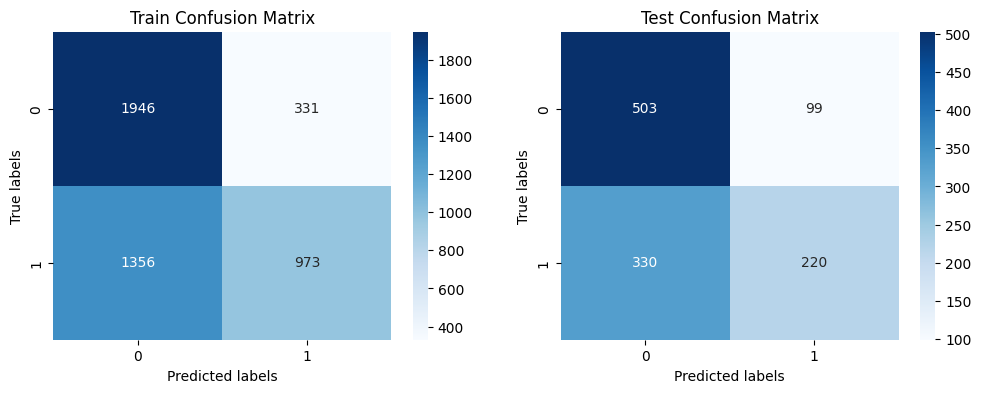

In [ ]:
# Visualizing evaluation Metric Score chart
model_metrics(y_train, y_test, y_train_nb_pred_gs, y_test_nb_pred_gs)

In [ ]:
# The Naive Bayes classifier was initially trained using the default
# parameters and achieved a test accuracy of 62.76% with a ROC-AUC score
# of 61.78%. The model showed relatively high precision but low recall,
# indicating that it correctly identified many predicted positive cases
# but failed to detect a substantial number of actual positive cases.
#
# Hyperparameter tuning was performed using cross-validation to optimize
# the model parameters. However, the tuned model produced identical
# performance to the baseline model, indicating that hyperparameter
# optimization did not improve the classifier.
#
# Both the baseline and tuned models achieved a test accuracy of 62.76%,
# precision of 68.97%, recall of 40.00%, and a ROC-AUC score of 61.78%.
# Likewise, the training metrics remained unchanged.
#
# The identical results suggest that the default hyperparameters were
# already optimal for this dataset or that the selected search space
# did not contain parameter values capable of improving performance.
#
# Therefore, the baseline Naive Bayes classifier was retained for further
# analysis and comparison, as hyperparameter tuning provided no measurable
# improvement in predictive performance.

Although the Random Forest and XGBoost classifiers achieved higher test accuracies (89.58% and 88.98%, respectively), both models exhibited perfect training performance (100% accuracy, precision, recall, and ROC-AUC), suggesting a higher risk of overfitting. In contrast, the Support Vector Machine (SVM) classifier achieved a lower but more consistent performance, with a training accuracy of 84.82% and a testing accuracy of 78.47%, indicating a relatively small generalization gap. This consistency suggests that the SVM model is less prone to overfitting and may provide more reliable predictions on unseen patient data. Consequently, the SVM classifier was selected as the final model due to its superior generalization capability and robustness.

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
import joblib

In [ ]:
# Save the trained model
joblib.dump(svc_best, "cadiovascular-risk-assessment.pkl")

['cadiovascular-risk-assessment.pkl']

In [ ]:
model = joblib.load("cadiovascular-risk-assessment.pkl")

In [ ]:
import joblib
import numpy as np

# Load model
model = joblib.load("cadiovascular-risk-assessment.pkl")

# Load scaler (IMPORTANT)
standard_scaler = joblib.load("scaler.pkl")

# ------------------------
# Patient input
# ------------------------
patient = np.array([[
    45, 1, 10, 0, 0, 1, 220, 140, 90, 28.5, 72, 85
]])

# Column order:
# age, sex, cigsPerDay, BPMeds, stroke, hypert, chol, sysBP, diaBP, BMI, heartRate, glucose

# ------------------------
# Step 1: separate features
# ------------------------
binary_cols = patient[:, [1,3,4,5]]      # sex, BPMeds, stroke, hypert
numeric_cols = patient[:, [0,2,6,7,8,9,10,11]]

# ------------------------
# Step 2: log transform numeric ONLY
# ------------------------
numeric_log = np.log1p(numeric_cols)

# ------------------------
# Step 3: scale numeric ONLY
# ------------------------
numeric_scaled = standard_scaler.transform(numeric_log)

# ------------------------
# Step 4: combine back
# ------------------------
final_input = np.concatenate([
    binary_cols,          # untouched (0/1)
    numeric_scaled        # transformed
], axis=1)

# ------------------------
# Prediction
# ------------------------
prediction = model.predict(final_input)[0]
probability = model.predict_proba(final_input)[0][1]

print("Prediction:", prediction)
print("Risk Probability:", probability)